# Audio & Speech EDA
- audio-feature correlation structure
- transcript word clouds
- transcript quality diagnostics
- non-alphabet / non-Latin noise detection
- Portuguese-dictionary coverage
- bigrams


## 1. Setup and data loading


In [17]:
import math
import os
import re
import unicodedata
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from wordcloud import WordCloud

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

FEATURES_DIR = '../Project_Features'


In [18]:
audio_files = sorted([f for f in os.listdir(FEATURES_DIR) if f.endswith('_audio.pkl')])
audio_dfs = []
for f in audio_files:
    df = pd.read_pickle(os.path.join(FEATURES_DIR, f))
    df['video'] = f.replace('_audio.pkl', '')
    audio_dfs.append(df)
data = pd.concat(audio_dfs, ignore_index=True)

def parse_embedding(x):
    if isinstance(x, np.ndarray):
        return x
    return np.fromstring(str(x).strip('[]'), sep=' ')

data['speak_embeddings'] = data['speak_embeddings'].apply(parse_embedding)
META = ['video', 'time stamp', 'duration', 'speak_embeddings']
scalar_cols = [c for c in data.columns if c not in META]
debate_videos = sorted([v for v in data['video'].unique() if 'vs' in v])

speech_files = sorted([f for f in os.listdir(FEATURES_DIR) if f.endswith('_speech.pkl')])
speech_dfs = []
for f in speech_files:
    df = pd.read_pickle(os.path.join(FEATURES_DIR, f))
    df['video'] = f.replace('_speech.pkl', '')
    speech_dfs.append(df)
data_speech = pd.concat(speech_dfs, ignore_index=True)
data_speech['word_count'] = data_speech['transcript'].apply(
    lambda t: len(str(t).split()) if pd.notnull(t) else 0
)
data_speech['words_per_sec'] = data_speech['word_count'] / data_speech['duration']
speech_debates = data_speech[data_speech['video'].isin(debate_videos)].copy()
speech_newscasts = data_speech[~data_speech['video'].isin(debate_videos)].copy()

print(f'Audio segments  (all files): {len(data)}')
print(f'Speech segments (all files): {len(data_speech)}')
print(f'Debate videos: {len(debate_videos)}')
print(f'Scalar audio features: {len(scalar_cols)}')
print(f'Debate speech segments: {len(speech_debates)}')
print(f'Newscast speech segments: {len(speech_newscasts)}')


Audio segments  (all files): 2656
Speech segments (all files): 1407
Debate videos: 28
Scalar audio features: 30
Debate speech segments: 843
Newscast speech segments: 564


## 1.1 Dataset overview & transcript quality diagnostics
- segment count and total speaking time per debate
- word-count and words-per-second distributions
- random character / non-Latin noise detection
- out-of-dictionary (non-Portuguese) token rate per segment
- filtering decision summary

In [19]:
PT_STOPWORDS = {
    'de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um', 'para', 'uma',
    'com', 'não', 'por', 'mais', 'as', 'dos', 'como', 'mas', 'foi', 'ao',
    'ele', 'das', 'tem', 'à', 'seu', 'sua', 'ou', 'ser', 'quando', 'muito',
    'há', 'nos', 'já', 'está', 'eu', 'também', 'só', 'pelo', 'pela', 'até',
    'isso', 'ela', 'entre', 'era', 'depois', 'sem', 'mesmo', 'aos', 'seus',
    'quem', 'nas', 'me', 'esse', 'eles', 'estão', 'você', 'tinha', 'foram',
    'essa', 'num', 'nem', 'suas', 'meu', 'às', 'minha', 'têm', 'numa',
    'pelos', 'pelas', 'qual', 'nós', 'lhe', 'deles', 'essas', 'esses',
    'pois', 'se', 'si', 'nessa', 'nesse', 'todo', 'toda', 'tudo', 'isto',
    'aqui', 'aquele', 'aquela', 'vos', 'lhes', 'cujo', 'cuja', 'nele',
    'dele', 'delas', 'nela', 'nos', 'na', 'no', 'ter', 'this', 'the',
    'são', 'este', 'esta', 'boa', 'noite', 'então', 'assim',
    'porque', 'temos', 'sobre', 'agora', 'bem', 'vai', 'pode',
    'vou', 'acho', 'anos', 'dizer', 'fazer', 'haver',
    'coisa', 'coisas', 'aquilo', 'portanto', 'aliás', 'claro', 'sim',
    'nada', 'nunca', 'sempre', 'ainda', 'hoje',
    'estou', 'estamos', 'estava', 'vamos', 'vão', 'sou', 'sabe', 'sei',
    'quer', 'quero', 'querem', 'podemos', 'deve', 'falar', 'faz', 'fez',
    'disse', 'diz', 'ver', 'dar', 'estar', 'sendo', 'tendo', 'sido',
    'pessoa', 'pessoas', 'gente', 'lado', 'parte', 'forma', 'vez', 'caso',
    'ponto', 'sentido', 'tempo', 'momento', 'exemplo', 'questão', 'verdade',
    'nosso', 'nossa', 'todos', 'outro', 'outros', 'outra',
    'alguém', 'ninguém', 'qualquer', 'mim', 'dois'
}

CUSTOM_PT_ALLOWLIST = {
    'gouveia', 'melo', 'gouveia-melo', 'marques', 'mendes', 'cotrim', 'figueiredo',
    'ventura', 'seguro', 'filipe', 'martins', 'pinto', 'ps', 'psd', 'cds', 'ch',
    'il', 'cdu', 'be', 'rtp', 'tvi', 'sic'
}
CUSTOM_PT_ALLOWLIST_PATHS = [
    Path('../dict/pt_custom_allowlist.txt'),
]


def clean_transcript_for_eda(text):
    text = str(text).lower()
    return re.sub(r'\s+', ' ', text).strip()


def tokenize_transcript(text, stopwords=None, min_len=3):
    stopwords = set() if stopwords is None else set(stopwords)
    tokens = re.findall(r"[a-zà-ÿ]+(?:-[a-zà-ÿ]+)?",
                        clean_transcript_for_eda(text), flags=re.IGNORECASE)
    return [t for t in tokens if len(t) >= min_len and t not in stopwords]


def tokenize_for_dictionary(text):
    return re.findall(r"[a-zà-ÿ]+(?:-[a-zà-ÿ]+)?",
                      clean_transcript_for_eda(text), flags=re.IGNORECASE)


def tokenize_for_dictionary_content(text):
    return tokenize_transcript(text, stopwords=PT_STOPWORDS, min_len=3)


def has_non_latin_script(text):
    return any(
        any(tag in unicodedata.name(ch, '')
            for tag in ('CYRILLIC', 'HIRAGANA', 'KATAKANA', 'CJK UNIFIED'))
        for ch in str(text)
    )


def strip_accents(text):
    return ''.join(
        ch for ch in unicodedata.normalize('NFD', str(text))
        if unicodedata.category(ch) != 'Mn'
    )


def load_custom_allowlist(paths):
    words = set()
    for path in paths:
        if path.exists():
            for line in path.read_text(encoding='utf-8', errors='ignore').splitlines():
                word = line.strip().lower()
                if word and not word.startswith('#'):
                    words.add(word)
    return words


def load_exact_wordlist(path):
    path = Path(path)
    lines = path.read_text(encoding='utf-8', errors='ignore').splitlines()
    if lines and lines[0].strip().isdigit():
        lines = lines[1:]
    words = set()
    for line in lines:
        word = line.split('/', 1)[0].strip().lower()
        if re.fullmatch(r"[a-zà-ÿ]+(?:-[a-zà-ÿ]+)?", word, flags=re.IGNORECASE):
            words.add(word)
    return words


def build_portuguese_checker():
    hunspell_candidates = [
        (Path('../dict/pt_PT.dic'), Path('../dict/pt_PT.aff')),
        (Path('dict/pt_PT.dic'), Path('dict/pt_PT.aff')),
        (Path('pt_PT.dic'), Path('pt_PT.aff')),
        (Path('pt-PT.dic'), Path('pt-PT.aff')),
        (Path('portuguese.dic'), Path('portuguese.aff')),
        (Path('/usr/share/hunspell/pt_PT.dic'), Path('/usr/share/hunspell/pt_PT.aff')),
        (Path('/usr/share/hunspell/pt-PT.dic'), Path('/usr/share/hunspell/pt-PT.aff')),
        (Path('/usr/share/hunspell/pt_BR.dic'), Path('/usr/share/hunspell/pt_BR.aff')),
    ]
    for dic_path, aff_path in hunspell_candidates:
        if dic_path.exists() and aff_path.exists():
            stem_words = {w.lower() for w in load_exact_wordlist(dic_path)}
            stem_words_folded = {strip_accents(w) for w in stem_words}

            def fallback(token, s=stem_words, sf=stem_words_folded):
                low = str(token).lower()
                return (low in s) or (strip_accents(low) in sf)

            try:
                from spylls.hunspell import Dictionary
                spell = Dictionary.from_files(str(dic_path.with_suffix('')))

                def spylls_check(token, sp=spell, fb=fallback):
                    return any(bool(sp.lookup(v))
                               for v in [token, token.lower(), token.title(), token.upper()]) or fb(token)
                return spylls_check, f'spylls: {dic_path}'
            except Exception:
                try:
                    import hunspell as hs
                    spell = hs.HunSpell(str(dic_path), str(aff_path))

                    def hunspell_check(token, sp=spell, fb=fallback):
                        return any(sp.spell(v)
                                   for v in [token, token.lower(), token.title(), token.upper()]) or fb(token)
                    return hunspell_check, f'hunspell: {dic_path}'
                except Exception:
                    pass

    for txt_path in [Path('portuguese_words.txt'), Path('pt_words.txt'), Path('pt_PT.txt')]:
        if txt_path.exists():
            words = {w.lower() for w in load_exact_wordlist(txt_path)}
            words_folded = {strip_accents(w) for w in words}

            def plain_check(token, ws=words, wsf=words_folded):
                low = str(token).lower()
                return (low in ws) or (strip_accents(low) in wsf)
            return plain_check, f'plain word list: {txt_path}'

    try:
        from wordfreq import zipf_frequency
        return lambda token: zipf_frequency(token, 'pt') > 0, 'wordfreq fallback'
    except Exception:
        return None, 'no Portuguese dictionary backend found'


def unique_preview(tokens, n=6):
    seen = []
    for tok in tokens:
        if tok not in seen:
            seen.append(tok)
        if len(seen) >= n:
            break
    return ', '.join(seen)


CUSTOM_PT_ALLOWLIST |= load_custom_allowlist(CUSTOM_PT_ALLOWLIST_PATHS)
CUSTOM_PT_ALLOWLIST_FOLDED = {strip_accents(w) for w in CUSTOM_PT_ALLOWLIST}


def is_portuguese_token(token, checker):
    token = str(token).lower()
    if token in CUSTOM_PT_ALLOWLIST or strip_accents(token) in CUSTOM_PT_ALLOWLIST_FOLDED:
        return True
    if checker is None:
        return None
    if checker(token):
        return True
    if '-' in token:
        parts = [p for p in token.split('-') if p]
        if parts and all((p in CUSTOM_PT_ALLOWLIST) or checker(p) for p in parts):
            return True
    return False


def compute_quality_flags(df, pt_checker):
    q = df.copy()
    q['transcript_str'] = q['transcript'].astype(str)
    q['char_count'] = q['transcript_str'].str.len()
    q['alpha_chars'] = q['transcript_str'].apply(lambda t: sum(ch.isalpha() for ch in str(t)))
    q['alpha_ratio'] = q['alpha_chars'] / q['char_count'].clip(lower=1)
    q['has_replacement_char'] = q['transcript_str'].str.contains('â€|ï¿½', regex=True)
    q['has_non_latin_script'] = q['transcript_str'].apply(has_non_latin_script)
    q['dict_tokens_content'] = q['transcript_str'].apply(tokenize_for_dictionary_content)
    if pt_checker is not None:
        unique_tokens = sorted({tok for toks in q['dict_tokens_content'] for tok in toks})
        token_is_pt = {tok: is_portuguese_token(tok, pt_checker) for tok in unique_tokens}
        q['ood_tokens'] = q['dict_tokens_content'].apply(
            lambda toks: [t for t in toks if token_is_pt.get(t) is False]
        )
        q['dict_token_count'] = q['dict_tokens_content'].apply(len)
        q['ood_count'] = q['ood_tokens'].apply(len)
        q['ood_ratio'] = q['ood_count'] / q['dict_token_count'].clip(lower=1)
        q['dictionary_coverage_flag'] = (q['ood_count'] >= 3) & (q['ood_ratio'] > 0.30)
        q['ood_examples'] = q['ood_tokens'].apply(unique_preview)
    else:
        q['dict_token_count'] = q['dict_tokens_content'].apply(len)
        q['ood_count'] = np.nan
        q['ood_ratio'] = np.nan
        q['dictionary_coverage_flag'] = False
        q['ood_tokens'] = [[] for _ in range(len(q))]
        q['ood_examples'] = ''
    wps_low, wps_high = q['words_per_sec'].quantile([0.01, 0.99])
    q['wps_outlier'] = (q['words_per_sec'] < wps_low) | (q['words_per_sec'] > wps_high)
    q['low_alpha_ratio'] = q['alpha_ratio'] < 0.65
    q['suspicious'] = (
        q['has_replacement_char'] | q['has_non_latin_script'] |
        q['wps_outlier'] | q['low_alpha_ratio'] | q['dictionary_coverage_flag']
    )
    return q


def flag_breakdown_chart(sq, ax, title):
    sq = sq.copy()
    def primary_flag(row):
        for f in FLAG_COLS:
            if row[f]:
                return f
        return 'clean'
    sq['primary_flag'] = sq.apply(primary_flag, axis=1)
    vf = sq.groupby(['video', 'primary_flag']).size().unstack(fill_value=0)
    for col in FLAG_COLS + ['clean']:
        if col not in vf.columns:
            vf[col] = 0
    vf['total'] = vf.sum(axis=1)
    vf['susp_share'] = (vf['total'] - vf['clean']) / vf['total'].clip(lower=1)
    vf = vf.sort_values('susp_share', ascending=True)
    plot_cols = ['clean'] + FLAG_COLS
    lefts = np.zeros(len(vf))
    for col in plot_cols:
        vals = vf[col].values if col in vf.columns else np.zeros(len(vf))
        ax.barh(range(len(vf)), vals, left=lefts,
                color=FLAG_COLORS[col], label=FLAG_LABELS[col],
                edgecolor='white', linewidth=0.3)
        lefts += vals
    ylabels = [v.replace('_vs_', ' vs ').replace('_', ' ')
                .replace('November', 'Nov').replace('December', 'Dec')
               for v in vf.index]
    ax.set_yticks(range(len(vf)))
    ax.set_yticklabels(ylabels, fontsize=7)
    ax.set_xlabel('Number of segments')
    ax.set_title(title, fontsize=10)
    ax.legend(loc='lower right', fontsize=8, framealpha=0.8)

Three views of transcript quality. The first histogram flags segments where less than 65% of characters are alphabetic. The stacked bar shows the breakdown per video sorted by how clean it is. The last two plots identify the specific tokens and characters that keep getting flagged.

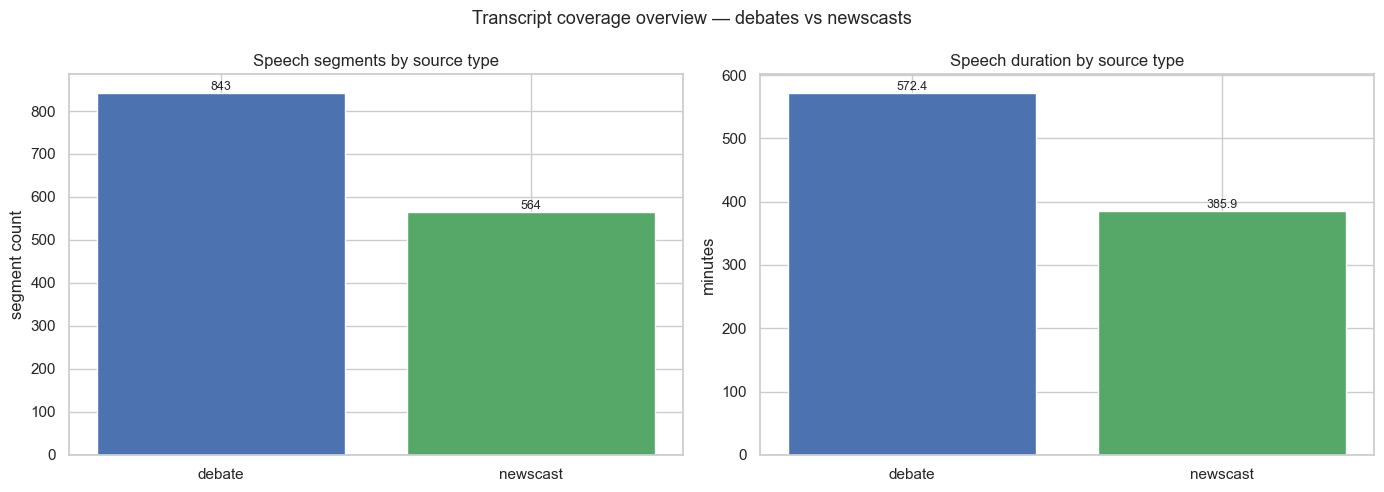

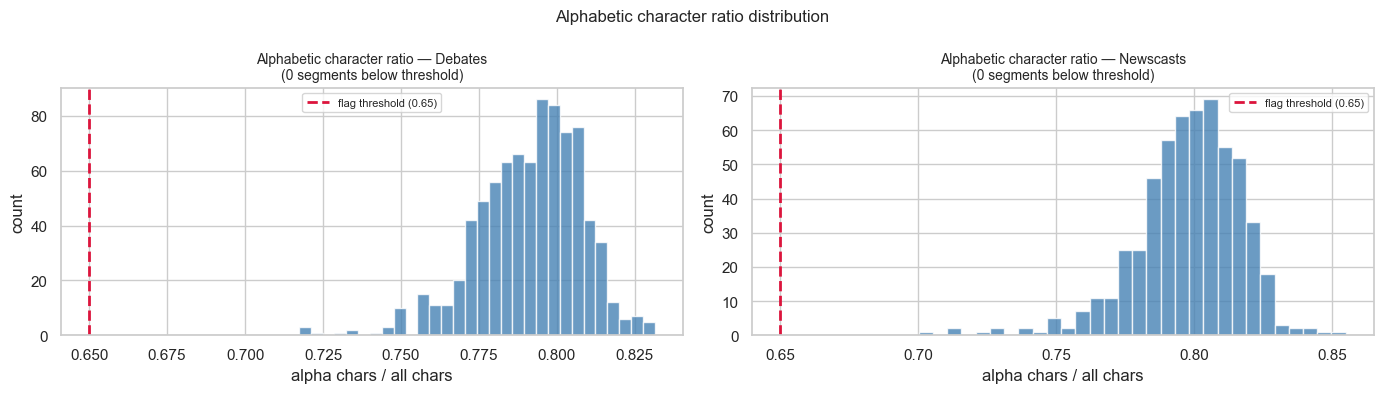

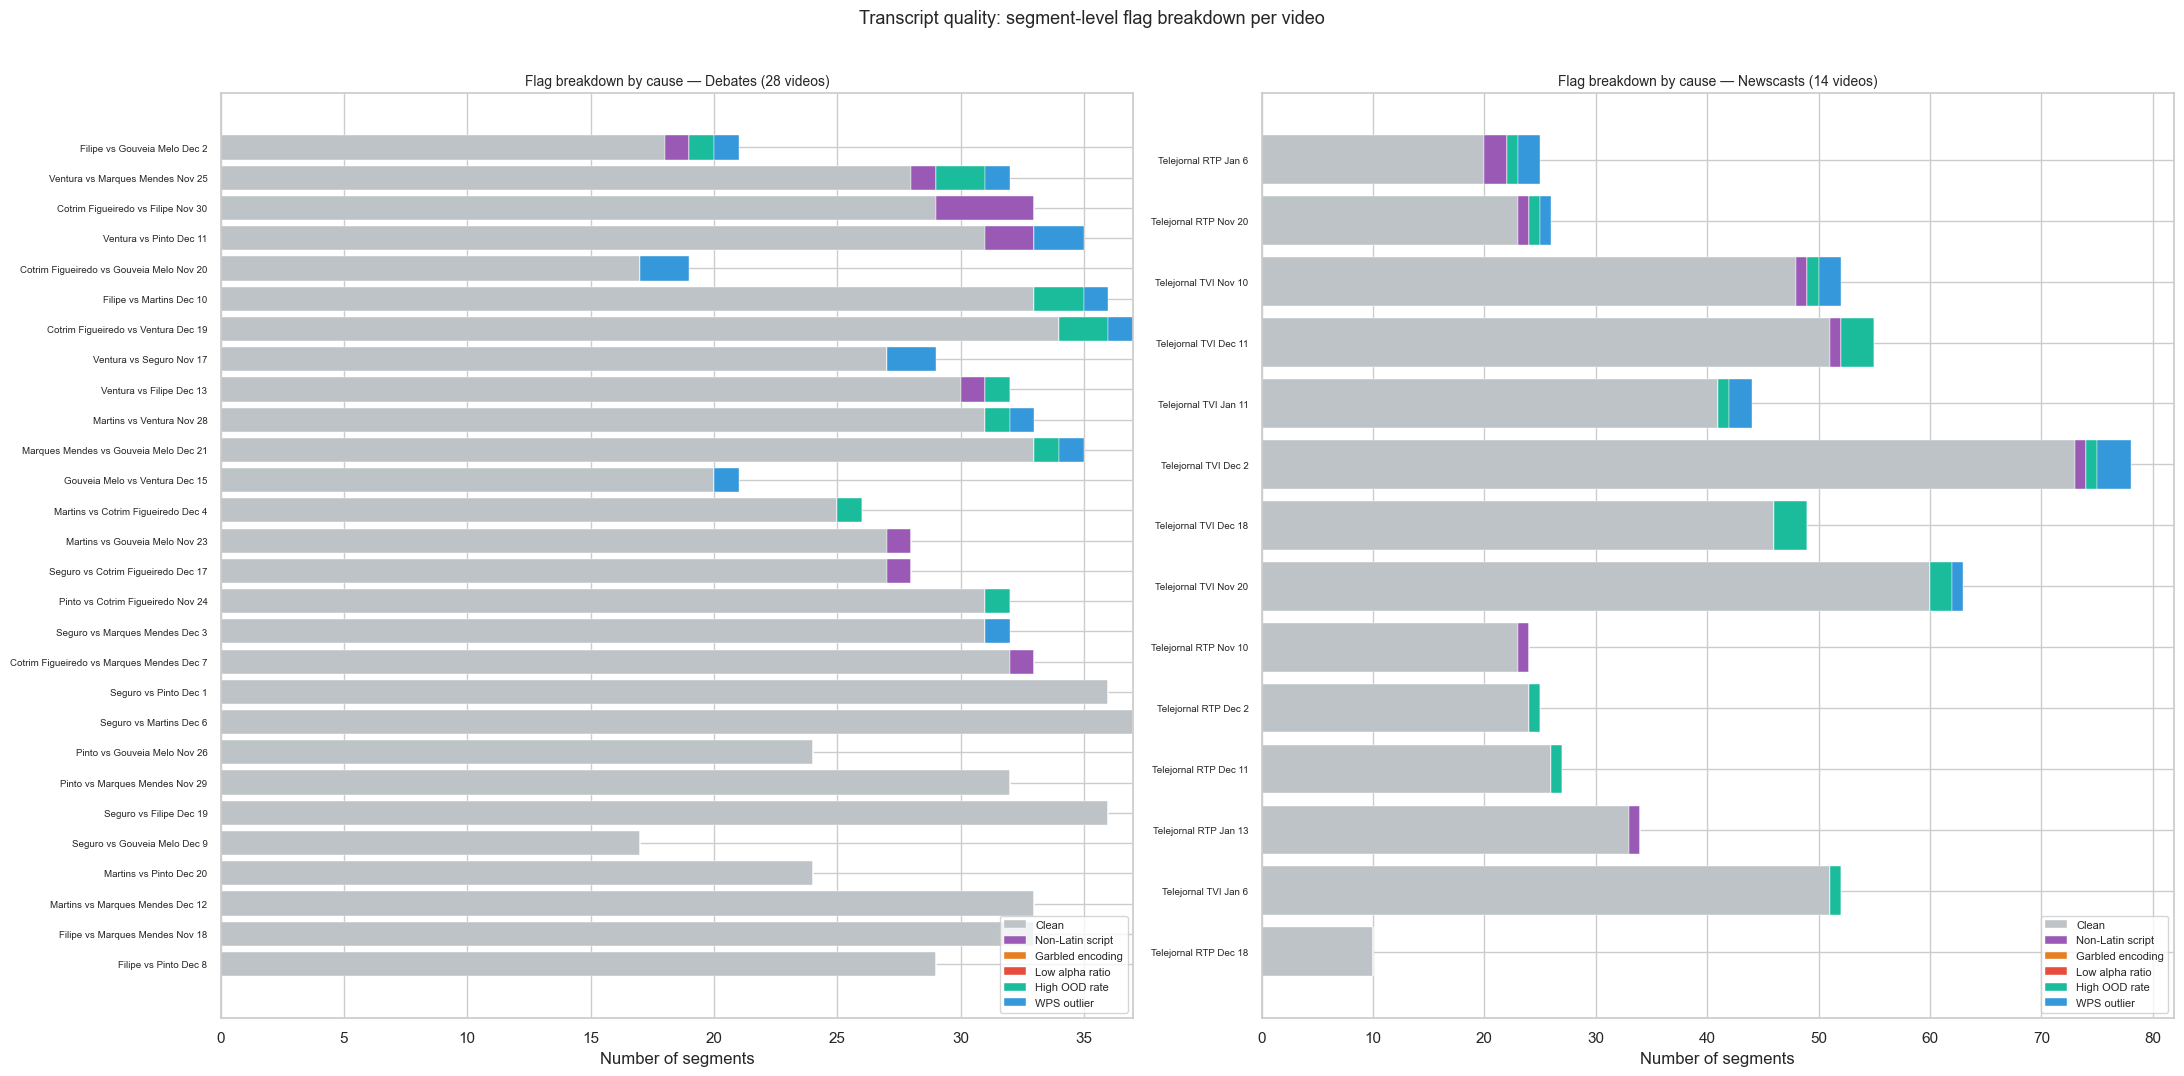

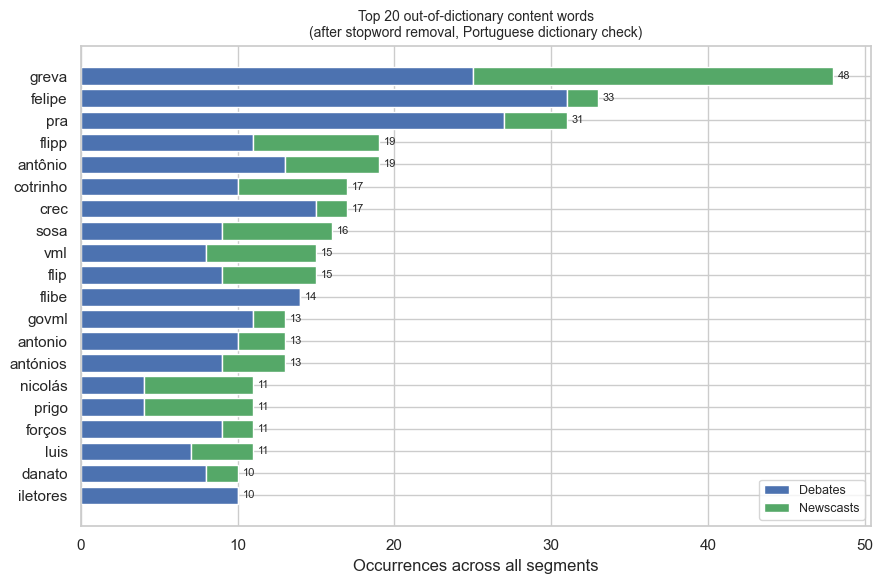

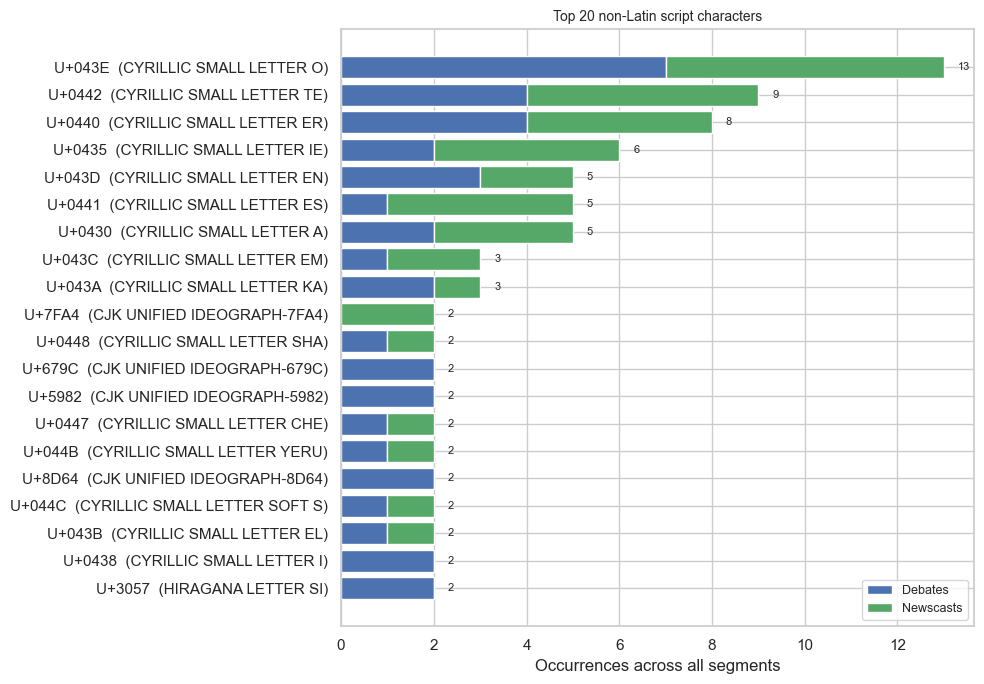

In [20]:
data_speech['content_type'] = np.where(data_speech['video'].isin(debate_videos), 'debate', 'newscast')
data['content_type'] = np.where(data['video'].isin(debate_videos), 'debate', 'newscast')

file_audio_stats = (
    data.groupby(['content_type', 'video'])
    .agg(n_segments=('duration', 'size'), total_duration_s=('duration', 'sum'))
    .reset_index()
)
file_speech_stats = (
    data_speech.groupby(['content_type', 'video'])
    .agg(n_speech_segs=('duration', 'size'), total_speech_s=('duration', 'sum'))
    .reset_index()
)
file_stats = file_audio_stats.merge(file_speech_stats, on=['content_type', 'video'], how='outer')

summary_by_type = (
    file_stats.groupby('content_type')
    .agg(
        n_files=('video', 'nunique'),
        audio_segments=('n_segments', 'sum'),
        audio_minutes=('total_duration_s', lambda s: s.sum() / 60),
        speech_segments=('n_speech_segs', 'sum'),
        speech_minutes=('total_speech_s', lambda s: s.sum() / 60),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = summary_by_type.set_index('content_type').loc[['debate', 'newscast']].reset_index()

axes[0].bar(plot_df['content_type'], plot_df['speech_segments'], color=['#4c72b0', '#55a868'], edgecolor='white')
axes[0].set_title('Speech segments by source type')
axes[0].set_ylabel('segment count')
for x, y in zip(plot_df['content_type'], plot_df['speech_segments']):
    axes[0].text(x, y, f'{int(y)}', ha='center', va='bottom', fontsize=9)

axes[1].bar(plot_df['content_type'], plot_df['speech_minutes'], color=['#4c72b0', '#55a868'], edgecolor='white')
axes[1].set_title('Speech duration by source type')
axes[1].set_ylabel('minutes')
for x, y in zip(plot_df['content_type'], plot_df['speech_minutes']):
    axes[1].text(x, y, f'{y:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Transcript coverage overview — debates vs newscasts', fontsize=13)
plt.tight_layout()
plt.show()

pt_checker, pt_checker_source = build_portuguese_checker()

speech_quality = compute_quality_flags(speech_debates, pt_checker)
speech_quality_news = compute_quality_flags(speech_newscasts, pt_checker)

FLAG_COLS = ['has_non_latin_script', 'has_replacement_char', 'low_alpha_ratio',
             'dictionary_coverage_flag', 'wps_outlier']
FLAG_LABELS = {
    'has_non_latin_script':     'Non-Latin script',
    'has_replacement_char':     'Garbled encoding',
    'low_alpha_ratio':          'Low alpha ratio',
    'dictionary_coverage_flag': 'High OOD rate',
    'wps_outlier':              'WPS outlier',
    'clean':                    'Clean',
}
FLAG_COLORS = {
    'has_non_latin_script':     '#9b59b6',
    'has_replacement_char':     '#e67e22',
    'low_alpha_ratio':          '#e74c3c',
    'dictionary_coverage_flag': '#1abc9c',
    'wps_outlier':              '#3498db',
    'clean':                    '#bdc3c7',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, sq, lbl in [(axes[0], speech_quality, 'Debates'),
                    (axes[1], speech_quality_news, 'Newscasts')]:
    ax.hist(sq['alpha_ratio'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
    ax.axvline(0.65, color='crimson', linestyle='--', linewidth=2, label='flag threshold (0.65)')
    n_flagged = int(sq['low_alpha_ratio'].sum())
    ax.set_title(f'Alphabetic character ratio — {lbl}\n({n_flagged} segments below threshold)', fontsize=10)
    ax.set_xlabel('alpha chars / all chars')
    ax.set_ylabel('count')
    ax.legend(fontsize=8)
plt.suptitle('Alphabetic character ratio distribution', fontsize=12)
plt.tight_layout()
plt.show()


n_dbt = speech_quality['video'].nunique()
n_news = speech_quality_news['video'].nunique()
fig_h = max(8, max(n_dbt, n_news) * 0.38)
fig, axes = plt.subplots(1, 2, figsize=(22, fig_h))
flag_breakdown_chart(speech_quality, axes[0], f'Flag breakdown by cause — Debates ({n_dbt} videos)')
flag_breakdown_chart(speech_quality_news, axes[1], f'Flag breakdown by cause — Newscasts ({n_news} videos)')
plt.suptitle('Transcript quality: segment-level flag breakdown per video', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


if pt_checker is not None:
    from collections import Counter as _Counter
    ood_all = _Counter(
        tok
        for sq in [speech_quality, speech_quality_news]
        for toks in sq['ood_tokens']
        for tok in toks
    )
    ood_dbt = _Counter(
        tok for toks in speech_quality['ood_tokens'] for tok in toks
    )
    ood_df = (
        pd.DataFrame(ood_all.most_common(20), columns=['token', 'total'])
        .assign(debates=lambda d: d['token'].map(lambda t: ood_dbt.get(t, 0)),
                newscasts=lambda d: d['total'] - d['token'].map(lambda t: ood_dbt.get(t, 0)))
        .sort_values('total', ascending=True)
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(ood_df['token'], ood_df['debates'], color='#4c72b0', label='Debates', edgecolor='white')
    ax.barh(ood_df['token'], ood_df['newscasts'], left=ood_df['debates'],
            color='#55a868', label='Newscasts', edgecolor='white')
    for i, (_, row) in enumerate(ood_df.iterrows()):
        ax.text(row['total'] + 0.3, i, str(int(row['total'])), va='center', fontsize=8)
    ax.set_xlabel('Occurrences across all segments')
    ax.set_title('Top 20 out-of-dictionary content words\n(after stopword removal, Portuguese dictionary check)', fontsize=10)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

# Figure 4: Most frequent non-Latin script characters
from collections import Counter as _CharCounter

_NON_LATIN_SCRIPTS = ('CYRILLIC', 'HIRAGANA', 'KATAKANA', 'CJK UNIFIED',
                      'ARABIC', 'HEBREW', 'GREEK', 'GEORGIAN', 'THAI')

_char_dbt  = _CharCounter()
_char_news = _CharCounter()
for _text in speech_quality['transcript_str']:
    for _ch in str(_text):
        _name = unicodedata.name(_ch, '')
        if any(_s in _name for _s in _NON_LATIN_SCRIPTS):
            _char_dbt[_ch] += 1
for _text in speech_quality_news['transcript_str']:
    for _ch in str(_text):
        _name = unicodedata.name(_ch, '')
        if any(_s in _name for _s in _NON_LATIN_SCRIPTS):
            _char_news[_ch] += 1

_all_chars = _char_dbt + _char_news
_top = _all_chars.most_common(20)

if _top:
    _chars  = [c for c, _ in _top]
    _labels = [f'U+{ord(c):04X}  ({unicodedata.name(c, "?")[:28]})' for c in _chars]
    _totals = [n for _, n in _top]
    _dbt_v  = [_char_dbt.get(c, 0)  for c in _chars]
    _news_v = [_char_news.get(c, 0) for c in _chars]
    _order  = sorted(range(len(_chars)), key=lambda i: _totals[i])

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh([_labels[i] for i in _order], [_dbt_v[i]  for i in _order],
            color='#4c72b0', label='Debates',  edgecolor='white')
    ax.barh([_labels[i] for i in _order], [_news_v[i] for i in _order],
            left=[_dbt_v[i] for i in _order],
            color='#55a868', label='Newscasts', edgecolor='white')
    for j, i in enumerate(_order):
        ax.text(_totals[i] + 0.3, j, str(_totals[i]), va='center', fontsize=8)
    ax.set_xlabel('Occurrences across all segments')
    ax.set_title('Top 20 non-Latin script characters', fontsize=10)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## 2. Audio feature correlations and Distributions


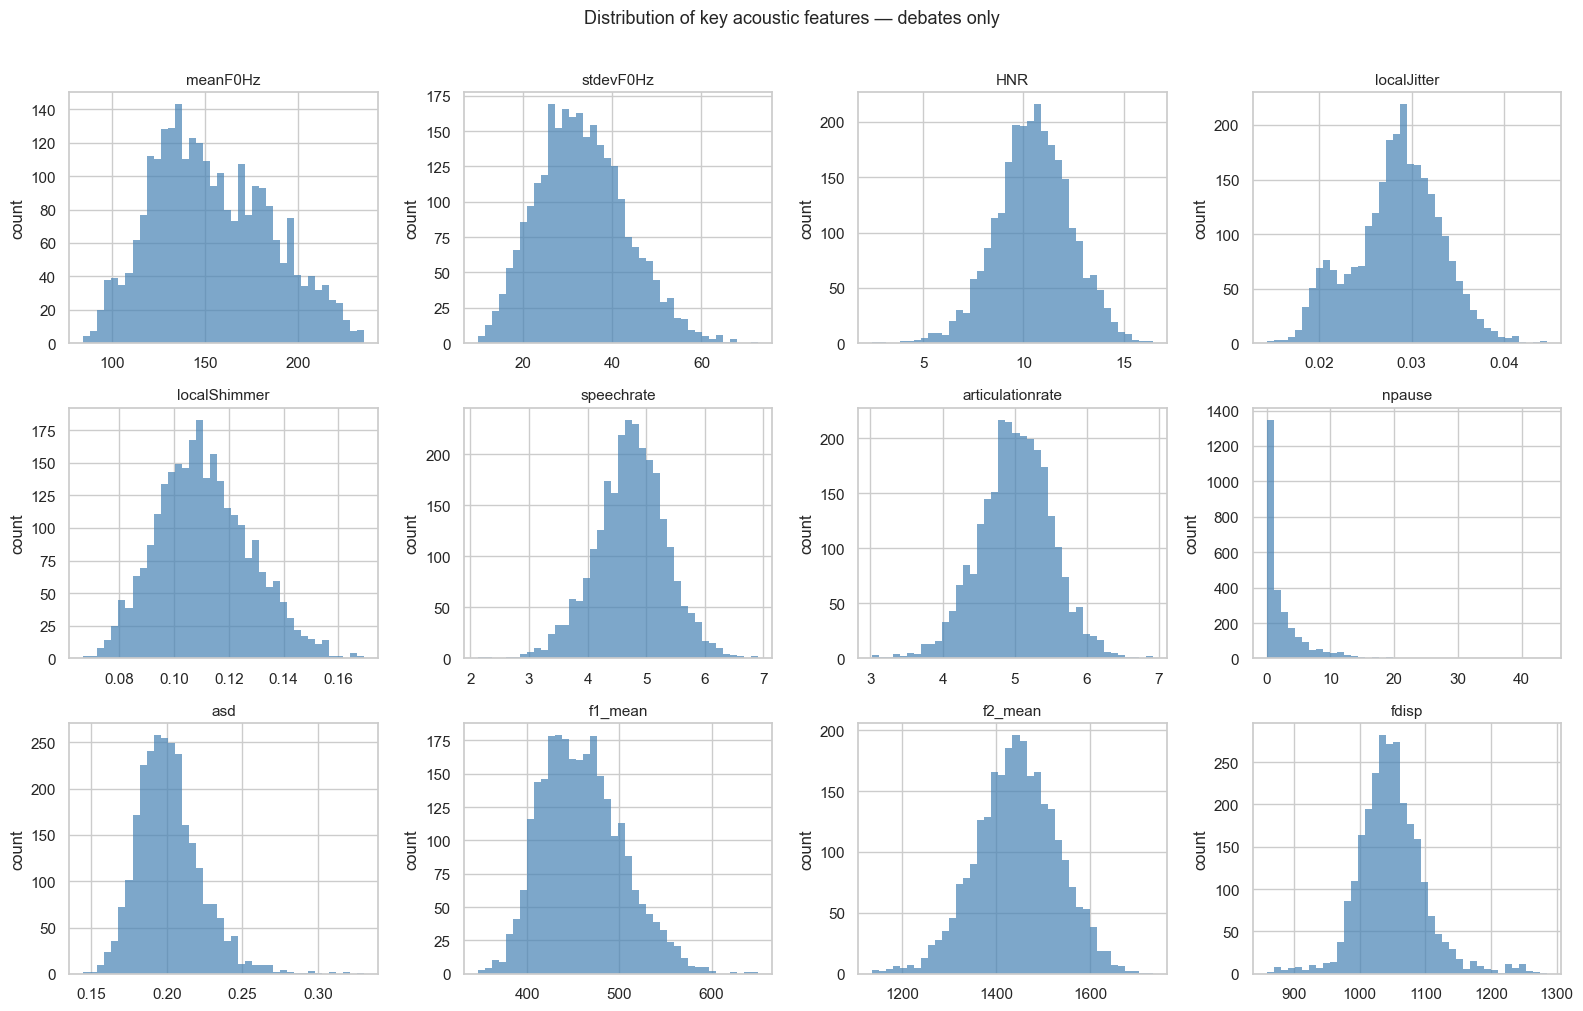

In [21]:
KEY_FEATURES = [
    'meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localShimmer',
    'speechrate', 'articulationrate', 'npause', 'asd',
    'f1_mean', 'f2_mean', 'fdisp',
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(KEY_FEATURES):
    axes[i].hist(data[data["video"].isin(debate_videos)][col].dropna(), bins=40, color='steelblue', alpha=0.7, edgecolor='none')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('count')

plt.suptitle('Distribution of key acoustic features — debates only', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

,feature_a,feature_b,correlation
0,apq3Shimmer,ddaShimmer,1.000
1,asd,articulationrate,-0.986
2,localShimmer,localdbShimmer,0.977
3,localShimmer,apq5Shimmer,0.959
4,f1_median,f1_mean,0.956
5,fdisp,f4_median,0.951
6,f2_mean,f2_median,0.951
7,f3_median,f3_mean,0.948
8,f4_mean,f4_median,0.942
9,ddaShimmer,apq5Shimmer,0.942


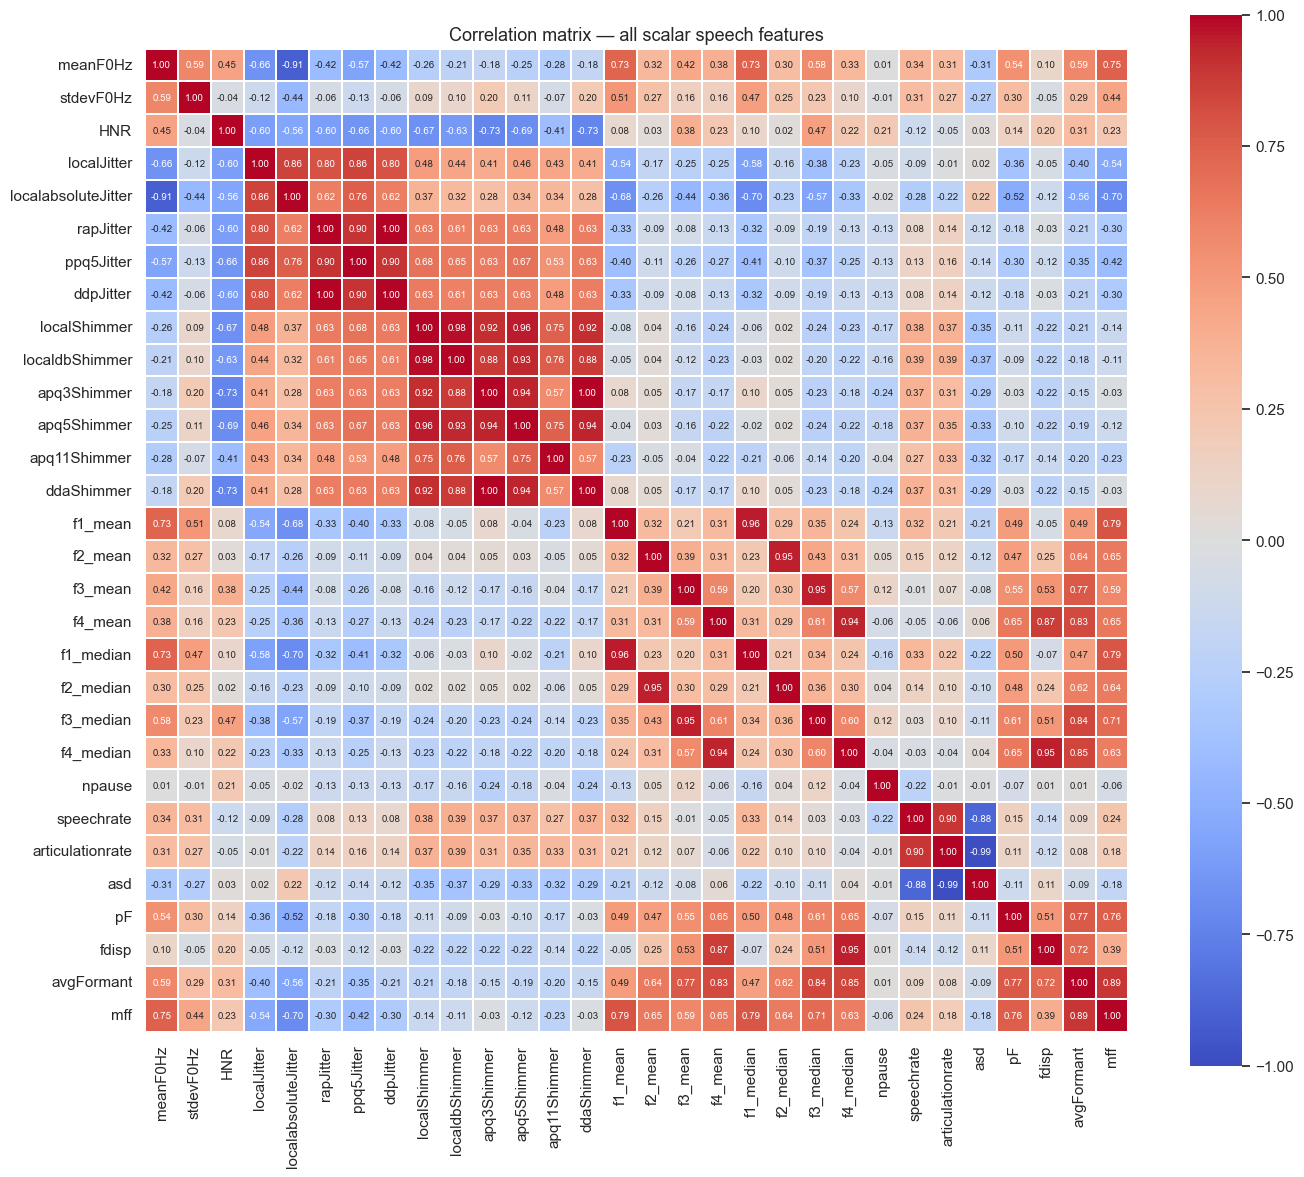

In [22]:
corr = data[scalar_cols].corr()
corr_vals = corr.abs().unstack()
corr_vals = corr_vals[corr_vals < 1.0]

seen = set()
rows = []
for (a, b), v in corr_vals.sort_values(ascending=False).items():
    key = tuple(sorted([a, b]))
    if key not in seen and v > 0.4:
        seen.add(key)
        rows.append({
            'feature_a': a,
            'feature_b': b,
            'correlation': round(corr.loc[a, b], 3)
        })

top_corr_df = pd.DataFrame(rows)
display(top_corr_df.head(20))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.3,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation matrix — all scalar speech features', fontsize=13)
plt.tight_layout()
plt.show()


### 2.1 Reduced audio feature set for later plots

Several acoustic variables are near-duplicates of one another. To avoid repeating the same signal,
the next cells keep one representative from the strongly correlated groups and reuse that reduced set
in the following plots.


,meanF0Hz,stdevF0Hz,HNR,localJitter,localShimmer,speechrate,npause,f1_mean,f2_mean,fdisp
meanF0Hz,1.000,0.588,0.449,-0.658,-0.265,0.344,0.007,0.733,0.322,0.104
stdevF0Hz,0.588,1.000,-0.035,-0.121,0.089,0.306,-0.014,0.514,0.270,-0.046
HNR,0.449,-0.035,1.000,-0.601,-0.675,-0.116,0.214,0.078,0.034,0.197
localJitter,-0.658,-0.121,-0.601,1.000,0.477,-0.093,-0.045,-0.541,-0.173,-0.050
localShimmer,-0.265,0.089,-0.675,0.477,1.000,0.383,-0.168,-0.079,0.036,-0.219
speechrate,0.344,0.306,-0.116,-0.093,0.383,1.000,-0.223,0.325,0.151,-0.139
npause,0.007,-0.014,0.214,-0.045,-0.168,-0.223,1.000,-0.133,0.052,0.006
f1_mean,0.733,0.514,0.078,-0.541,-0.079,0.325,-0.133,1.000,0.316,-0.053
f2_mean,0.322,0.270,0.034,-0.173,0.036,0.151,0.052,0.316,1.000,0.246
fdisp,0.104,-0.046,0.197,-0.050,-0.219,-0.139,0.006,-0.053,0.246,1.000


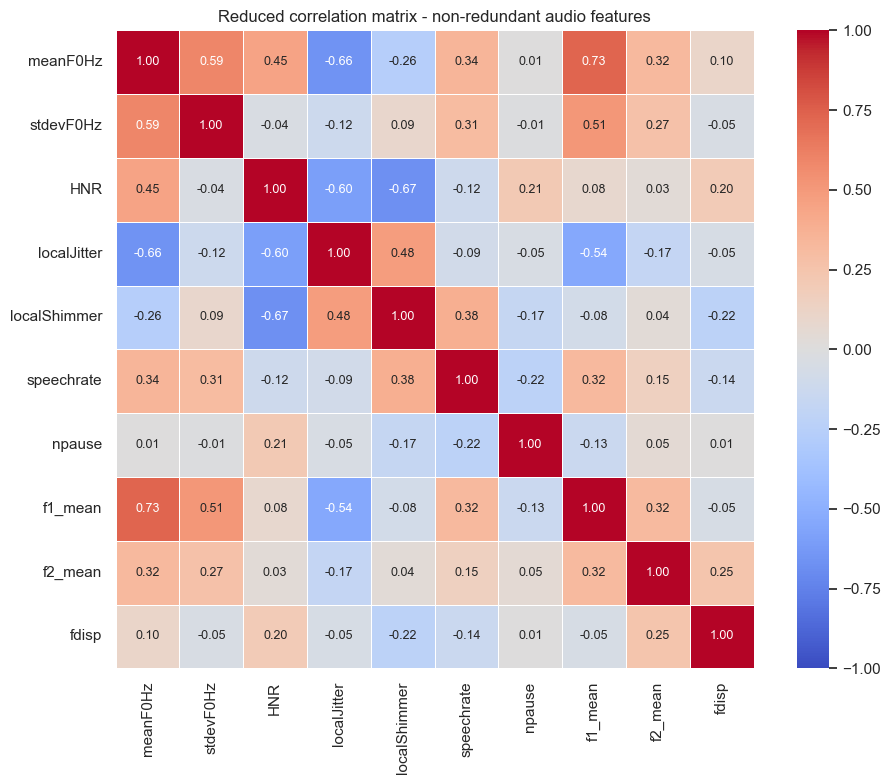

Features kept for later time-series plots:
['meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localShimmer', 'speechrate']


In [23]:
NON_REDUNDANT = [
    'meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localShimmer',
    'speechrate', 'npause', 'f1_mean', 'f2_mean', 'fdisp'
]
FEATURES_OVER_TIME = [
    'meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localShimmer', 'speechrate'
]

reduced_corr = data[NON_REDUNDANT].corr()
display(reduced_corr.round(3))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    reduced_corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.4,
    annot_kws={'size': 9},
    ax=ax
)
ax.set_title('Reduced correlation matrix - non-redundant audio features', fontsize=12)
plt.tight_layout()
plt.show()

print('Features kept for later time-series plots:')
print(FEATURES_OVER_TIME)


## 3. Single-debate speaker-cluster case study
 
The debate`Martins_vs_Gouveia_Melo_November_23` is used here as an unlabeled cluster demonstration.


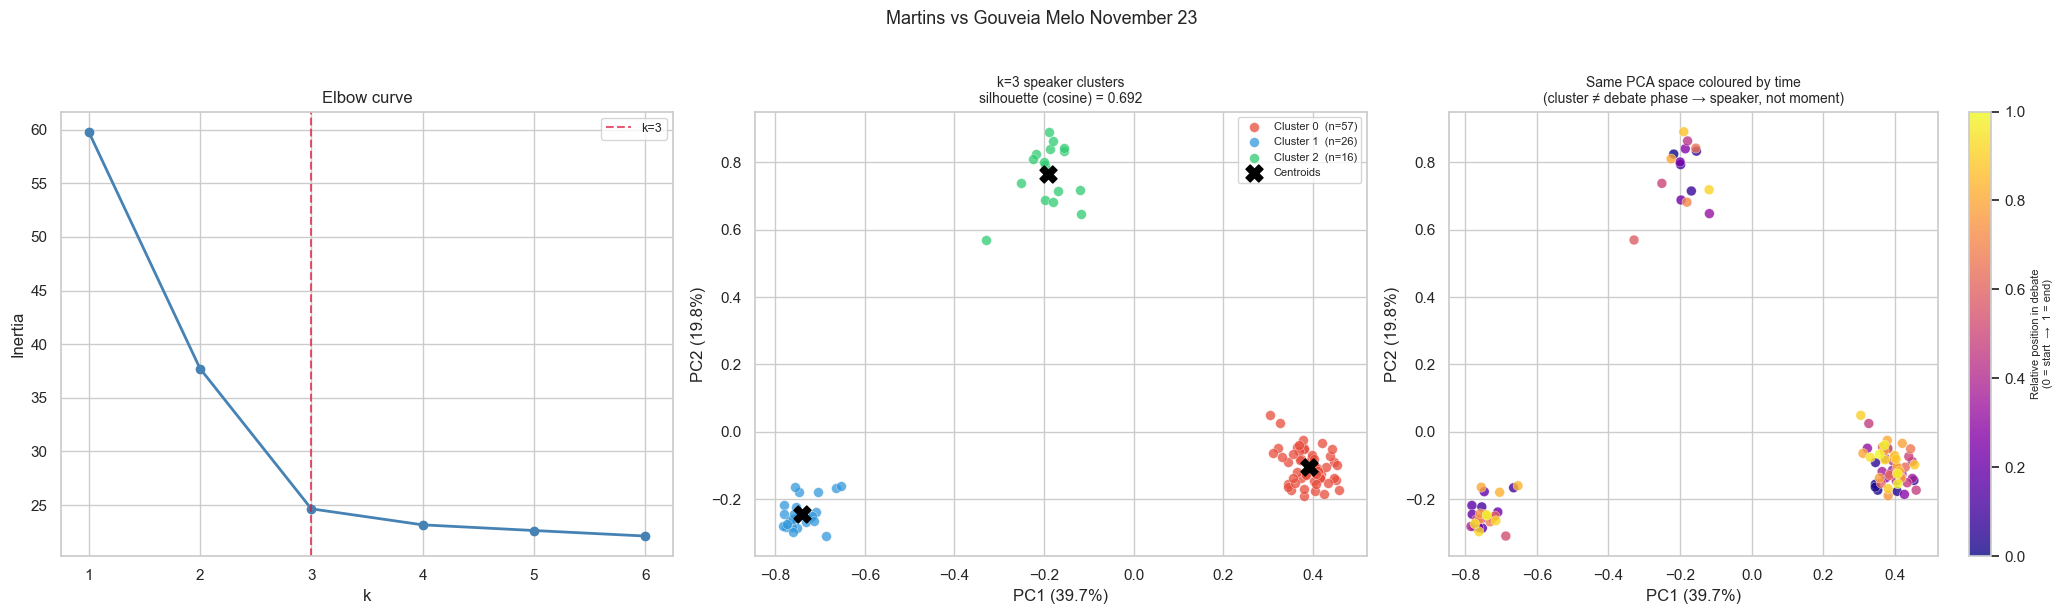

Silhouette score for Martins_vs_Gouveia_Melo_November_23: 0.692


In [24]:
DEMO_DEBATE = 'Martins_vs_Gouveia_Melo_November_23'

demo_dbt = data[data['video'] == DEMO_DEBATE].copy().reset_index(drop=True)
E = np.stack(demo_dbt['speak_embeddings'].values)

pca = PCA(n_components=2, random_state=42)
E_2d = pca.fit_transform(E)
var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

ks = range(1, 7)
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(E).inertia_ for k in ks]

km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_k3 = km3.fit_predict(E)
sil = silhouette_score(E, labels_k3, metric='cosine')

demo_dbt['cluster_k3'] = labels_k3
cluster_colors = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71'}
cluster_labels = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

# time normalised to [0,1] within this debate for temporal coloring
demo_sorted = demo_dbt.sort_values('time stamp').reset_index(drop=True)
t_min, t_max = demo_sorted['time stamp'].min(), demo_sorted['time stamp'].max()
t_norm = (demo_sorted['time stamp'] - t_min) / max(t_max - t_min, 1)
E_2d_sorted = pca.transform(np.stack(demo_sorted['speak_embeddings'].values))
centroids_2d = pca.transform(km3.cluster_centers_)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle(DEMO_DEBATE.replace('_', ' '), fontsize=13, y=1.02)

# panel 1: elbow
axes[0].plot(list(ks), inertias, marker='o', linewidth=2, color='steelblue')
axes[0].axvline(x=3, color='crimson', linestyle='--', alpha=0.7, label='k=3')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow curve')
axes[0].legend(fontsize=9)

# panel 2: k=3 cluster scatter (larger, silhouette in title)
cluster_palette = ['#e74c3c', '#3498db', '#2ecc71']
for i in range(3):
    mask = labels_k3 == i
    axes[1].scatter(
        E_2d[mask, 0], E_2d[mask, 1],
        c=cluster_palette[i], label=f'Cluster {i}  (n={mask.sum()})',
        alpha=0.75, s=50, edgecolors='white', linewidth=0.3
    )
axes[1].scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    c='black', marker='X', s=150, zorder=5, label='Centroids'
)
axes[1].set_title(f'k=3 speaker clusters\nsilhouette (cosine) = {sil:.3f}', fontsize=10)
axes[1].set_xlabel(f'PC1 ({var1:.1f}%)')
axes[1].set_ylabel(f'PC2 ({var2:.1f}%)')
axes[1].legend(fontsize=8)

# panel 3: same PCA space coloured by temporal position
sc = axes[2].scatter(
    E_2d_sorted[:, 0], E_2d_sorted[:, 1],
    c=t_norm, cmap='plasma',
    alpha=0.8, s=50, edgecolors='white', linewidth=0.3
)
cbar = plt.colorbar(sc, ax=axes[2])
cbar.set_label('Relative position in debate\n(0 = start  →  1 = end)', fontsize=8)
axes[2].set_title('Same PCA space coloured by time\n(cluster ≠ debate phase → speaker, not moment)', fontsize=10)
axes[2].set_xlabel(f'PC1 ({var1:.1f}%)')
axes[2].set_ylabel(f'PC2 ({var2:.1f}%)')

plt.tight_layout()
plt.show()

print(f'Silhouette score for {DEMO_DEBATE}: {sil:.3f}')


### 3.1 Silhouette score for k=3 across all debates
Computes the silhouette score for k=3 on every debate, so the consistency is visible.

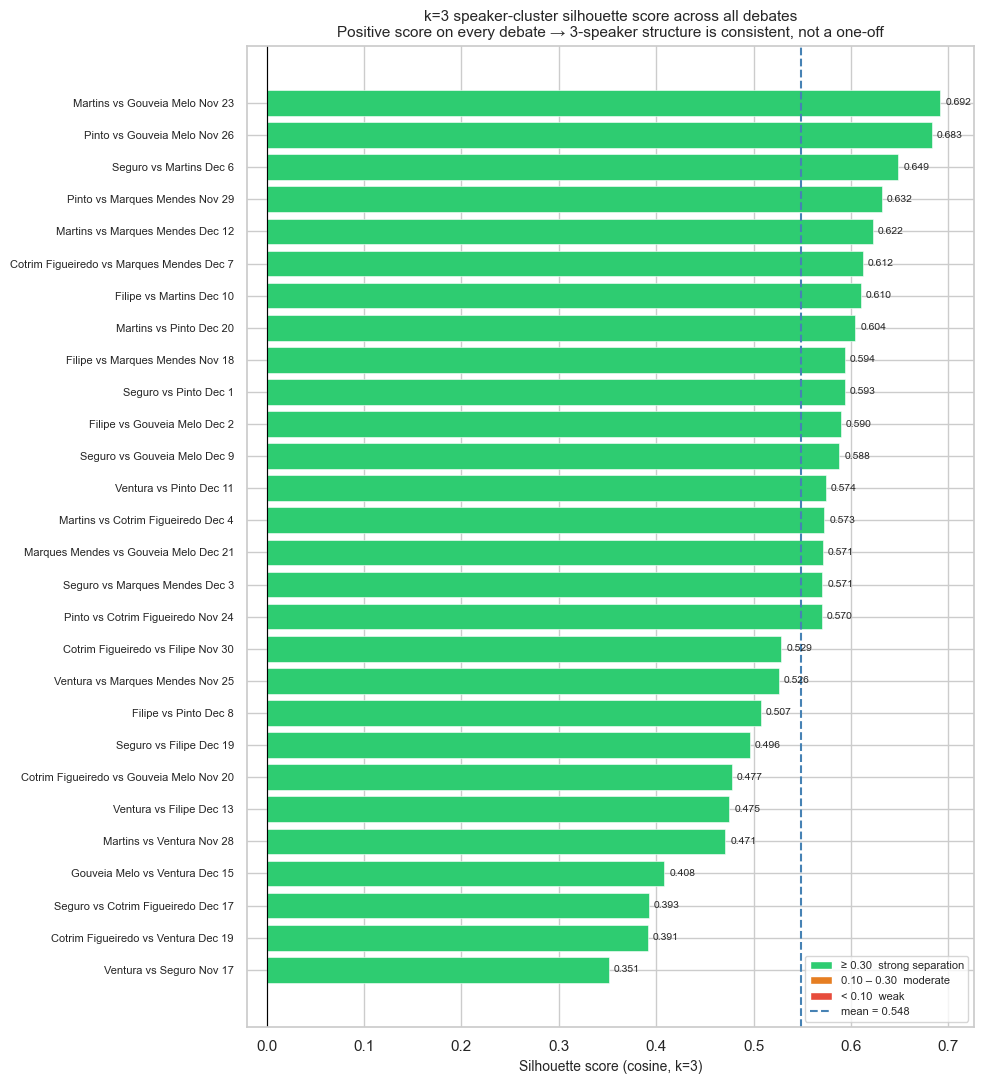

Debates: 28 | mean silhouette: 0.548 | median: 0.572
Strong (≥0.30): 28 | Moderate (0.10–0.30): 0 | Weak (<0.10): 0


In [25]:
sil_rows = []
for video in debate_videos:
    sub = data[data['video'] == video]
    if len(sub) < 4:
        continue
    E_v = np.stack(sub['speak_embeddings'].values)
    km = KMeans(n_clusters=3, random_state=42, n_init=10)
    lbl = km.fit_predict(E_v)
    if len(np.unique(lbl)) < 3:
        continue
    s = silhouette_score(E_v, lbl, metric='cosine')
    sil_rows.append({'debate': video.replace('_vs_', ' vs ').replace('_', ' ')
                                   .replace('November', 'Nov').replace('December', 'Dec'),
                     'silhouette': s,
                     'n_segments': len(sub)})

sil_df = pd.DataFrame(sil_rows).sort_values('silhouette', ascending=True).reset_index(drop=True)

mean_sil = sil_df['silhouette'].mean()
median_sil = sil_df['silhouette'].median()

bar_colors = ['#2ecc71' if s >= 0.3 else '#e67e22' if s >= 0.1 else '#e74c3c'
              for s in sil_df['silhouette']]

fig, ax = plt.subplots(figsize=(10, 11))
bars = ax.barh(sil_df['debate'], sil_df['silhouette'], color=bar_colors, edgecolor='white', linewidth=0.4)
ax.axvline(mean_sil, color='steelblue', linestyle='--', linewidth=1.5, label=f'mean = {mean_sil:.3f}')
ax.axvline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, sil_df['silhouette']):
    ax.text(max(val + 0.005, 0.005), bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left', fontsize=7.5)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='≥ 0.30  strong separation'),
    Patch(facecolor='#e67e22', label='0.10 – 0.30  moderate'),
    Patch(facecolor='#e74c3c', label='< 0.10  weak'),
    plt.Line2D([0], [0], color='steelblue', linestyle='--', linewidth=1.5, label=f'mean = {mean_sil:.3f}'),
]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')

ax.set_xlabel('Silhouette score (cosine, k=3)', fontsize=10)
ax.set_title('k=3 speaker-cluster silhouette score across all debates\n'
             'Positive score on every debate → 3-speaker structure is consistent, not a one-off', fontsize=11)
ax.tick_params(axis='y', labelsize=8)
ax.set_xlim(left=min(sil_df['silhouette'].min() - 0.05, -0.02))
plt.tight_layout()
plt.show()

print(f'Debates: {len(sil_df)} | mean silhouette: {mean_sil:.3f} | median: {median_sil:.3f}')
print(f'Strong (≥0.30): {(sil_df["silhouette"] >= 0.30).sum()} | '
      f'Moderate (0.10–0.30): {((sil_df["silhouette"] >= 0.10) & (sil_df["silhouette"] < 0.30)).sum()} | '
      f'Weak (<0.10): {(sil_df["silhouette"] < 0.10).sum()}')


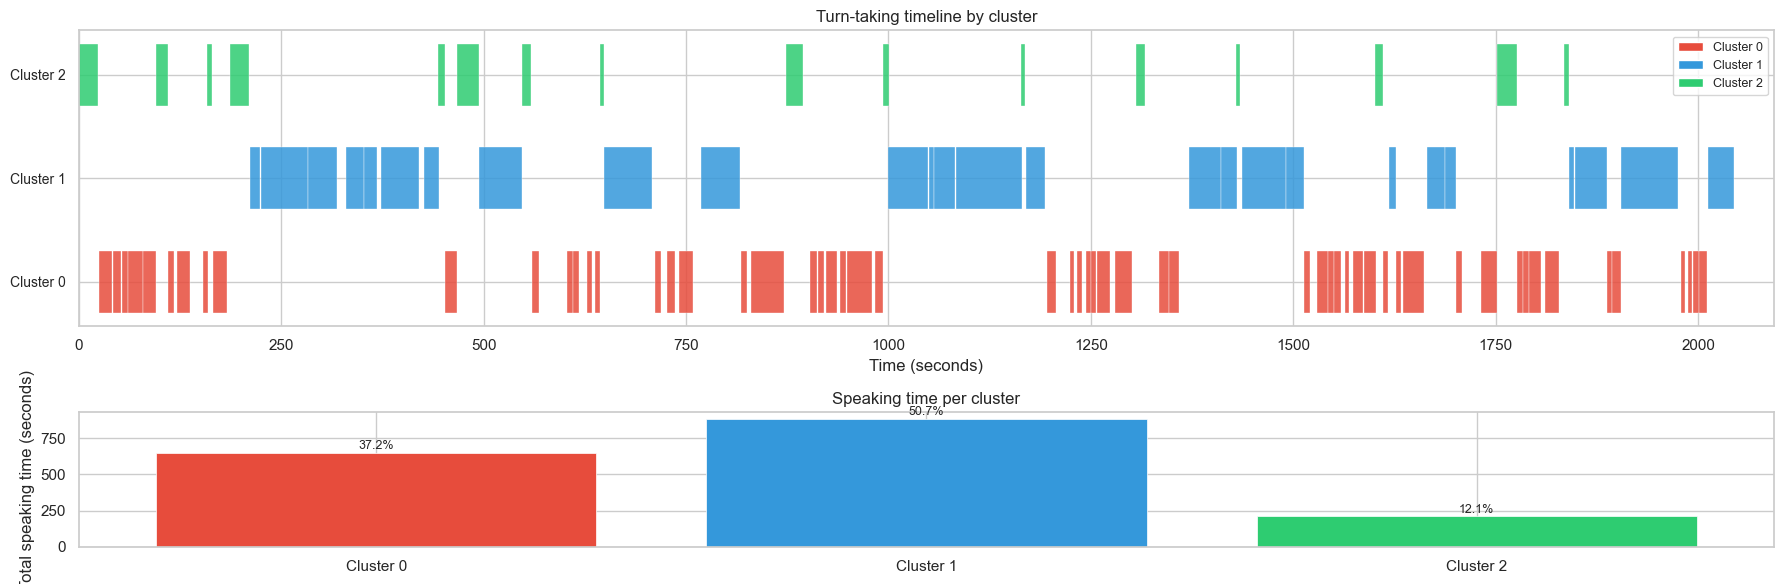

Turn statistics by cluster - Martins_vs_Gouveia_Melo_November_23:
  Cluster 0: 57 segments | mean duration 11.4s | median 8.7s | total 648s
  Cluster 1: 26 segments | mean duration 34.0s | median 29.3s | total 883s
  Cluster 2: 16 segments | mean duration 13.2s | median 10.4s | total 210s


In [26]:
demo_dbt = demo_dbt.sort_values('time stamp').reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(18, 6), gridspec_kw={'height_ratios': [2.2, 1]})

timeline_ax = axes[0]
for _, row in demo_dbt.iterrows():
    c = int(row['cluster_k3'])
    timeline_ax.barh(
        y=c,
        width=row['duration'],
        left=row['time stamp'],
        height=0.6,
        color=cluster_colors[c],
        alpha=0.85,
        edgecolor='white',
        linewidth=0.3
    )

timeline_ax.set_yticks([0, 1, 2])
timeline_ax.set_yticklabels([cluster_labels[i] for i in [0, 1, 2]], fontsize=10)
timeline_ax.set_xlabel('Time (seconds)')
timeline_ax.set_title('Turn-taking timeline by cluster')
timeline_ax.set_xlim(0, demo_dbt['time stamp'].max() + demo_dbt['duration'].max())

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cluster_colors[i], label=cluster_labels[i]) for i in [0, 1, 2]]
timeline_ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

time_per_cluster = demo_dbt.groupby('cluster_k3')['duration'].sum().reindex([0, 1, 2], fill_value=0)
total_time = time_per_cluster.sum()

bar_ax = axes[1]
bars = bar_ax.bar(
    [cluster_labels[i] for i in [0, 1, 2]],
    time_per_cluster.values,
    color=[cluster_colors[i] for i in [0, 1, 2]],
    edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars, time_per_cluster.values):
    pct = 100 * val / max(total_time, 1)
    bar_ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{pct:.1f}%', ha='center', va='bottom', fontsize=9
    )

bar_ax.set_ylabel('Total speaking time (seconds)')
bar_ax.set_title('Speaking time per cluster')

plt.tight_layout()
plt.show()

print(f'Turn statistics by cluster - {DEMO_DEBATE}:')
for c in [0, 1, 2]:
    sub = demo_dbt[demo_dbt['cluster_k3'] == c]
    print(
        f'  Cluster {c}: {len(sub)} segments | '
        f'mean duration {sub["duration"].mean():.1f}s | '
        f'median {sub["duration"].median():.1f}s | '
        f'total {sub["duration"].sum():.0f}s'
    )


### 3.2 Audio features over time by speaker cluster

C:\Users\dinis\AppData\Local\Temp\ipykernel_3944\352379679.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


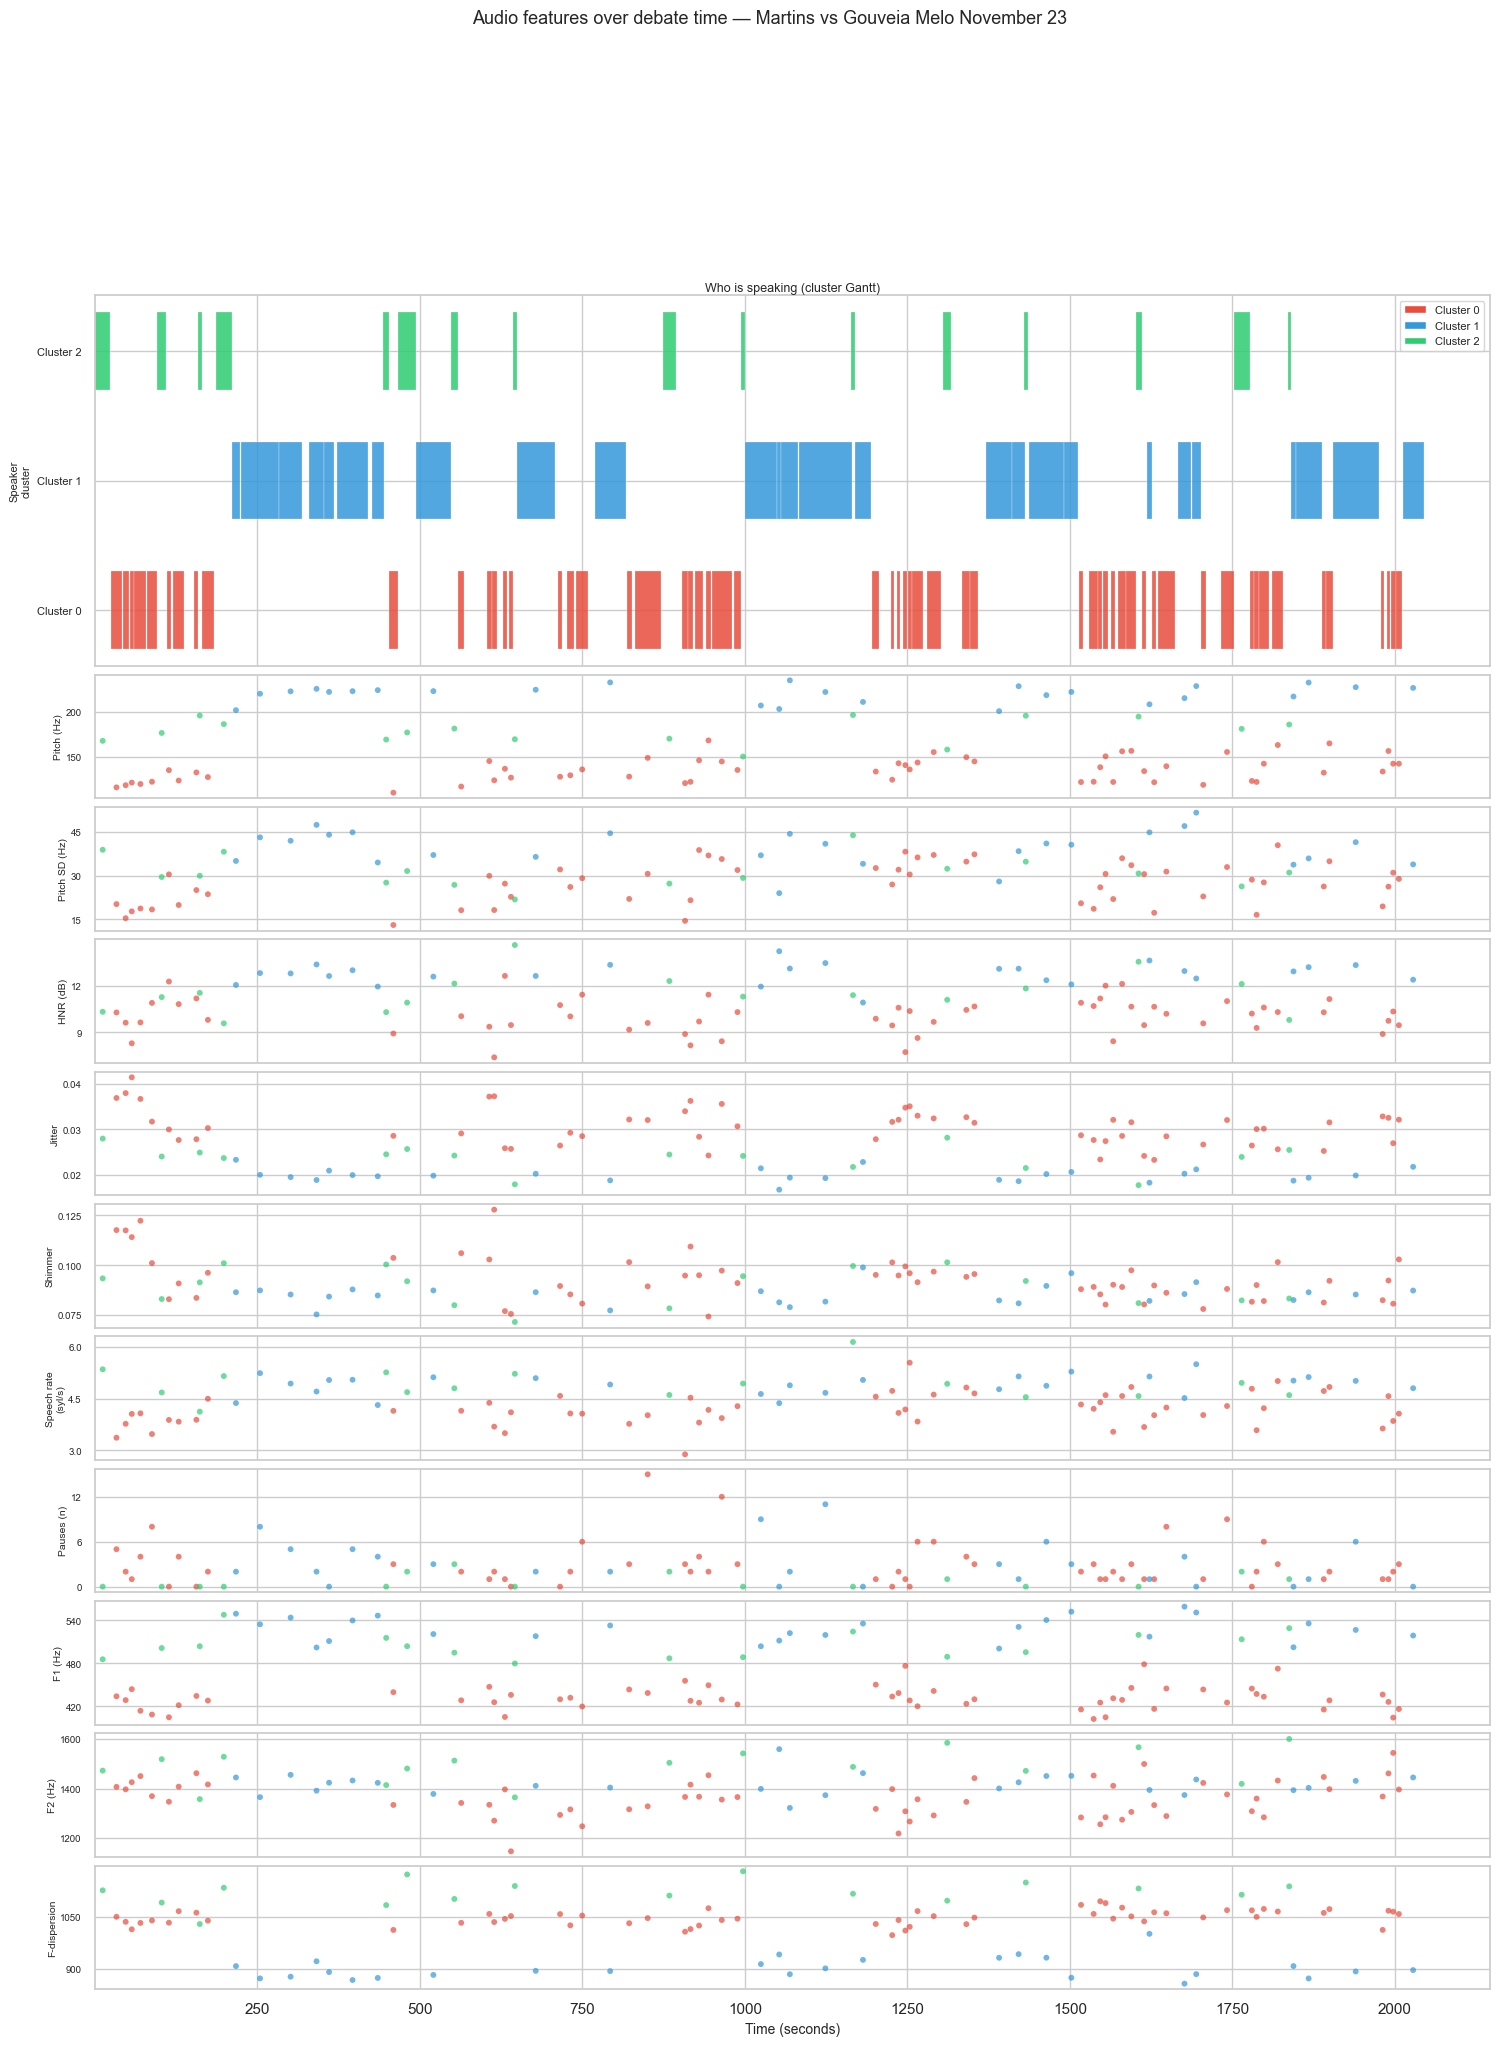

In [27]:
FEATURES_TIMELINE = [
    'meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localShimmer',
    'speechrate', 'npause', 'f1_mean', 'f2_mean', 'fdisp'
]
FEATURE_LABELS = {
    'meanF0Hz':    'Pitch (Hz)',
    'stdevF0Hz':   'Pitch SD (Hz)',
    'HNR':         'HNR (dB)',
    'localJitter': 'Jitter',
    'localShimmer':'Shimmer',
    'speechrate':  'Speech rate\n(syl/s)',
    'npause':      'Pauses (n)',
    'f1_mean':     'F1 (Hz)',
    'f2_mean':     'F2 (Hz)',
    'fdisp':       'F-dispersion',
}

demo_timeline = demo_dbt.sort_values('time stamp').reset_index(drop=True)
demo_timeline['seg_mid'] = demo_timeline['time stamp'] + demo_timeline['duration'] / 2

n_feats = len(FEATURES_TIMELINE)
height_ratios = [3] + [1] * n_feats

fig, axes = plt.subplots(
    n_feats + 1, 1,
    figsize=(18, 4 + n_feats * 1.8),
    sharex=True,
    gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.06}
)
fig.suptitle(
    f'Audio features over debate time — {DEMO_DEBATE.replace("_", " ")}',
    fontsize=13, y=1.01
)

# row 0: cluster Gantt
for _, row in demo_timeline.iterrows():
    c = int(row['cluster_k3'])
    axes[0].barh(
        y=c, width=row['duration'], left=row['time stamp'],
        height=0.6, color=cluster_colors[c], alpha=0.85,
        edgecolor='white', linewidth=0.2
    )
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels([cluster_labels[i] for i in [0, 1, 2]], fontsize=8)
axes[0].set_ylabel('Speaker\ncluster', fontsize=8)
axes[0].set_title('Who is speaking (cluster Gantt)', fontsize=9, pad=3)
from matplotlib.patches import Patch as _P
axes[0].legend(
    handles=[_P(facecolor=cluster_colors[i], label=cluster_labels[i]) for i in [0, 1, 2]],
    loc='upper right', fontsize=8
)

# rows 1‥n: scatter dots per feature, colored by cluster
for ax_idx, feat in enumerate(FEATURES_TIMELINE, start=1):
    ax = axes[ax_idx]
    for c in [0, 1, 2]:
        mask = demo_timeline['cluster_k3'] == c
        ax.scatter(
            demo_timeline.loc[mask, 'seg_mid'],
            demo_timeline.loc[mask, feat],
            c=cluster_colors[c], s=18, alpha=0.70, edgecolors='none'
        )
    ax.set_ylabel(FEATURE_LABELS.get(feat, feat), fontsize=7.5, labelpad=2)
    ax.yaxis.set_major_locator(plt.MaxNLocator(3))
    ax.tick_params(axis='y', labelsize=7)

axes[-1].set_xlabel('Time (seconds)', fontsize=10)
plt.tight_layout()
plt.show()


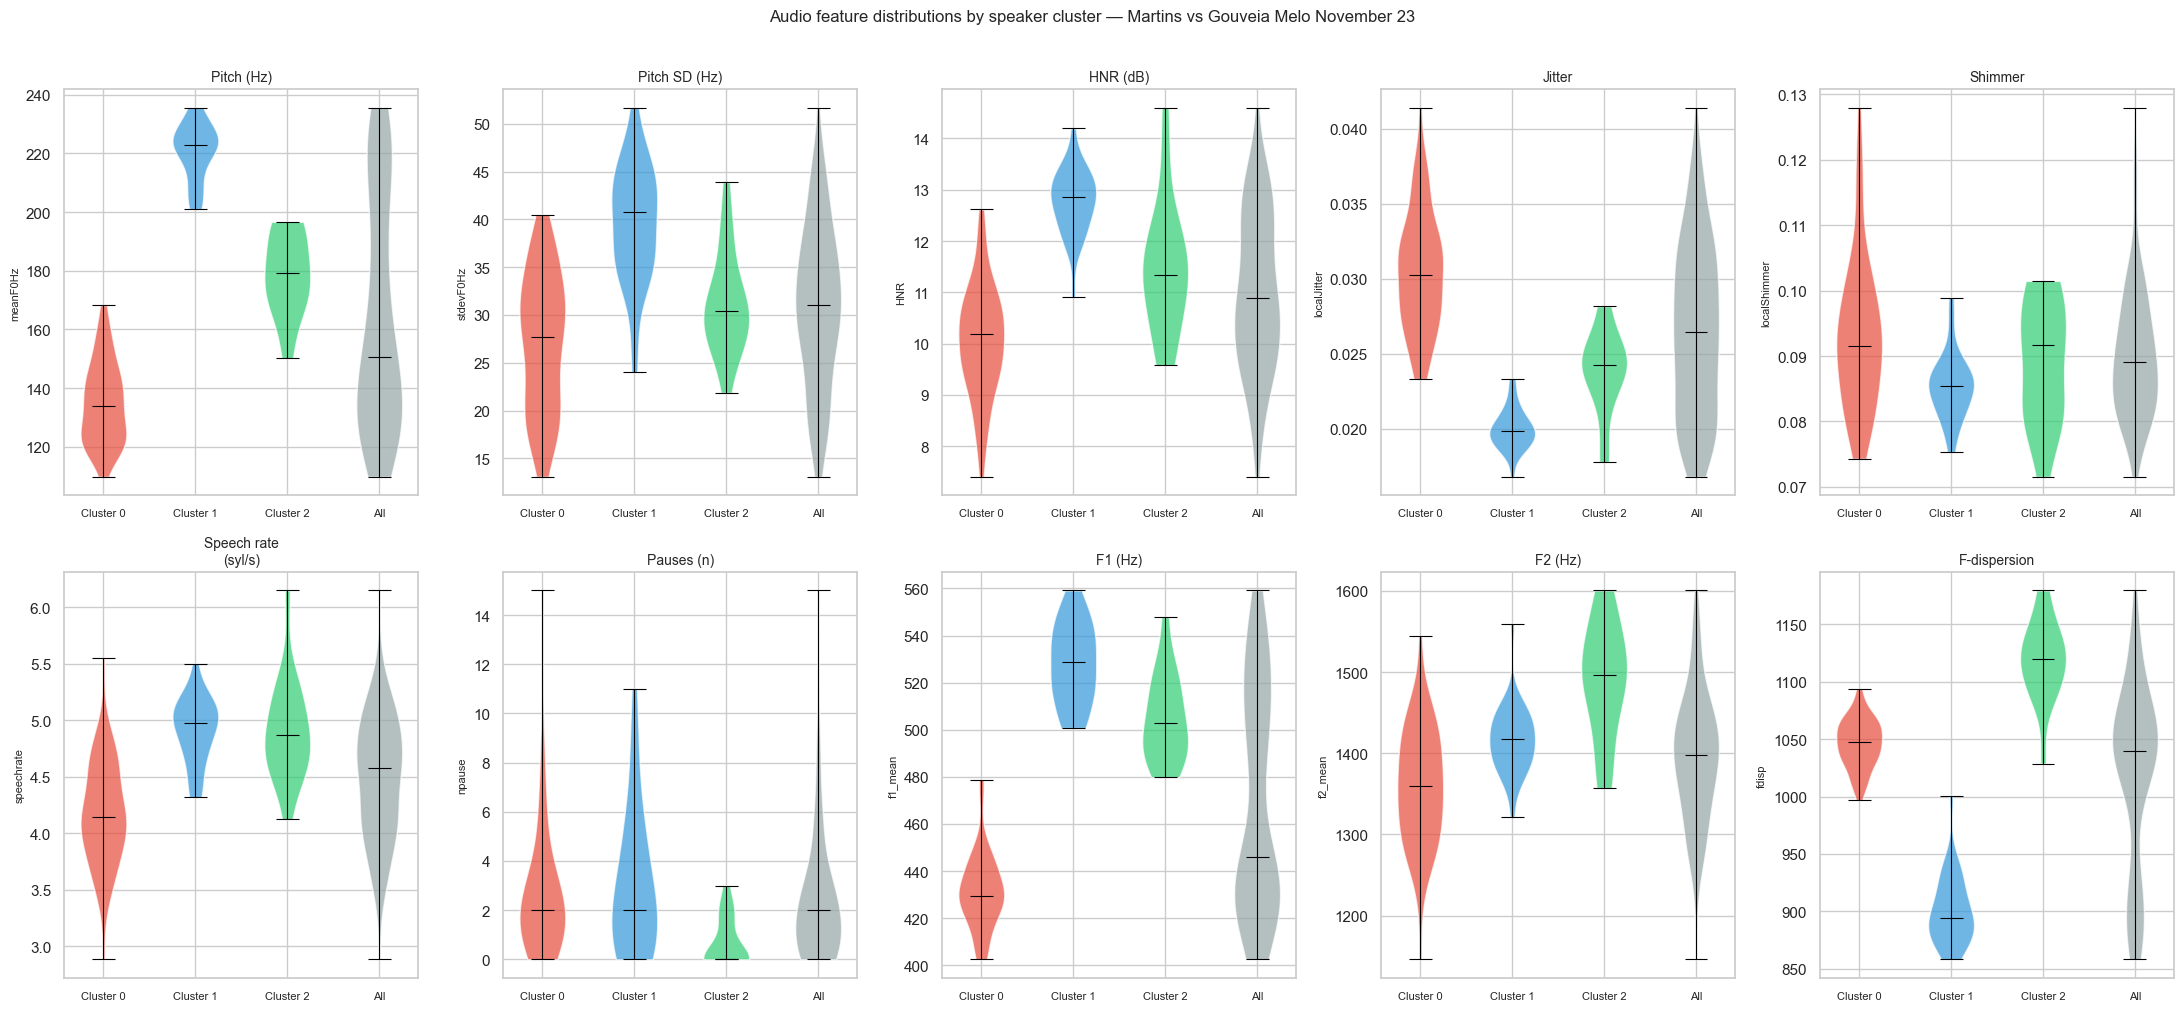

In [28]:
# Positions: 0=Cluster 0, 1=Cluster 1, 2=Cluster 2, 3=All (global)
violin_colors = [cluster_colors[0], cluster_colors[1], cluster_colors[2], '#95a5a6']
x_labels = [cluster_labels[i] for i in [0, 1, 2]] + ['All']

ncols = 5
nrows = math.ceil(len(FEATURES_TIMELINE) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(22, 5 * nrows))
fig.suptitle(
    f'Audio feature distributions by speaker cluster — {DEMO_DEBATE.replace("_", " ")}',
    fontsize=12, y=1.01
)
axes = axes.flatten()

for ax_idx, feat in enumerate(FEATURES_TIMELINE):
    ax = axes[ax_idx]
    groups = [
        demo_dbt.loc[demo_dbt['cluster_k3'] == c, feat].dropna().values
        for c in [0, 1, 2]
    ] + [demo_dbt[feat].dropna().values]

    parts = ax.violinplot(groups, positions=[0, 1, 2, 3], showmedians=True, showextrema=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(violin_colors[i])
        pc.set_alpha(0.70)
    for part_name in ('cmedians', 'cmins', 'cmaxes', 'cbars'):
        parts[part_name].set_edgecolor('black')
        parts[part_name].set_linewidth(0.8)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_title(FEATURE_LABELS.get(feat, feat), fontsize=10)
    ax.set_ylabel(feat, fontsize=8)

for ax_idx in range(len(FEATURES_TIMELINE), len(axes)):
    axes[ax_idx].axis('off')

plt.tight_layout()
plt.show()


## 5. Word clouds

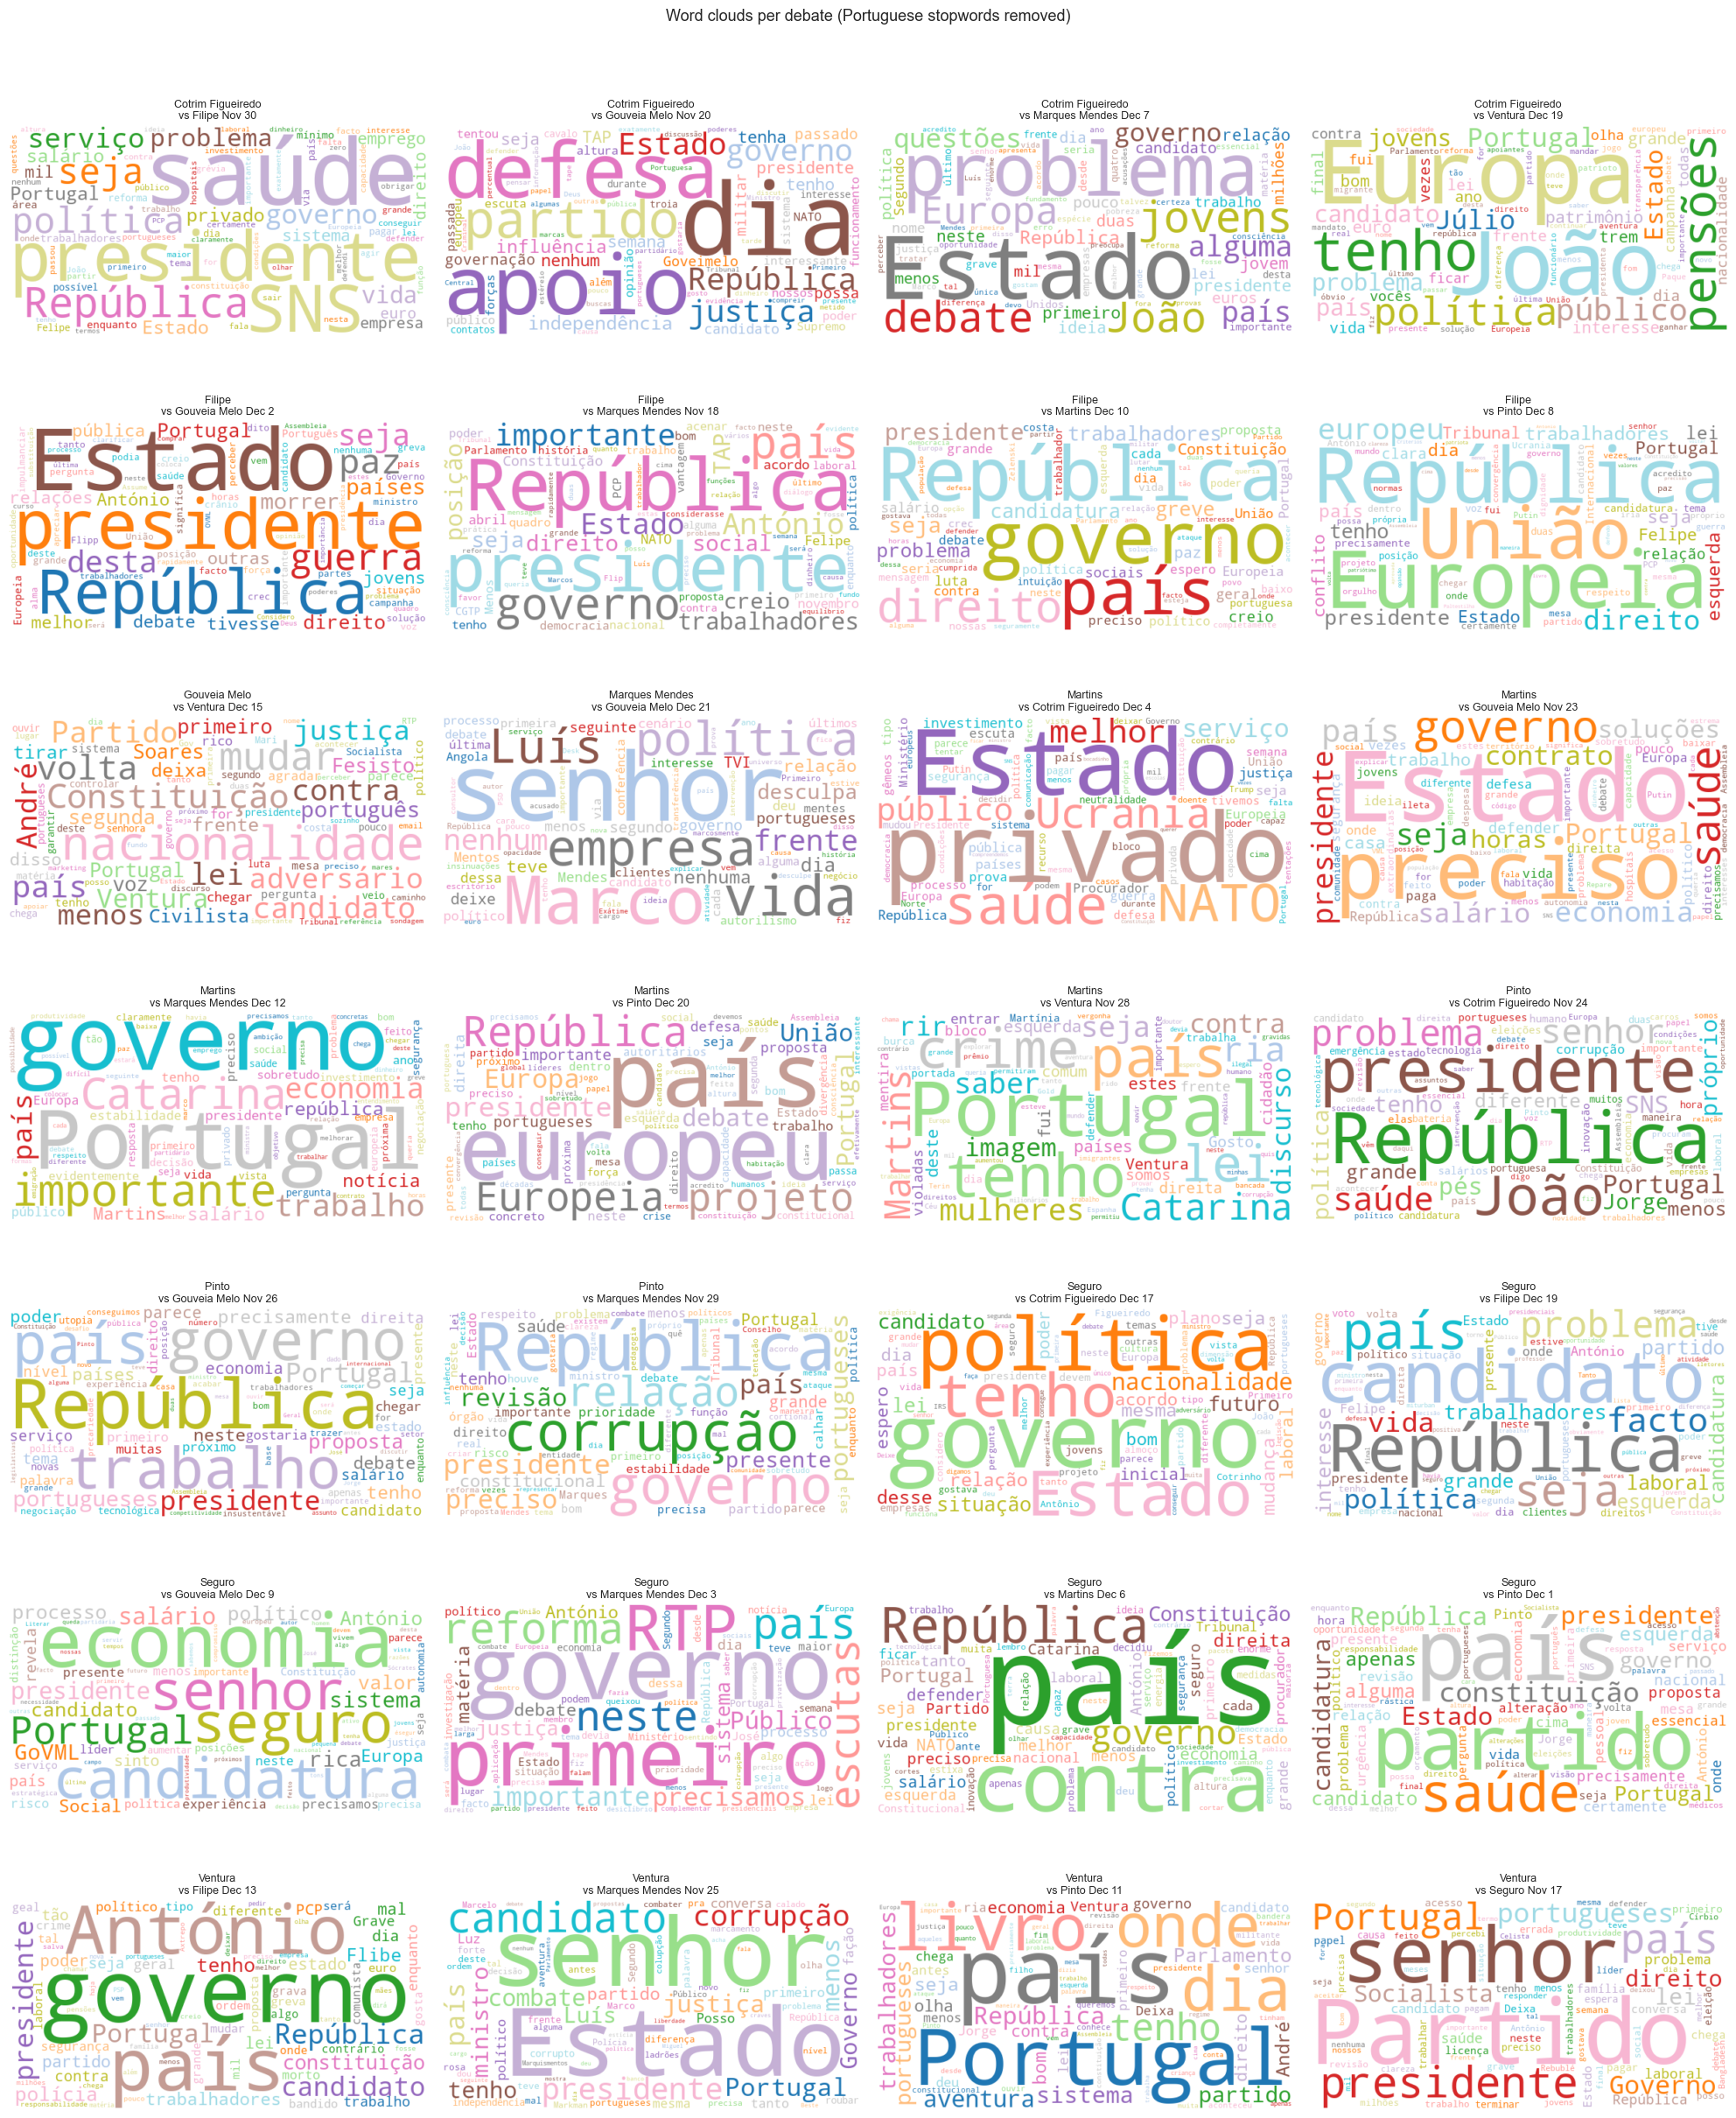

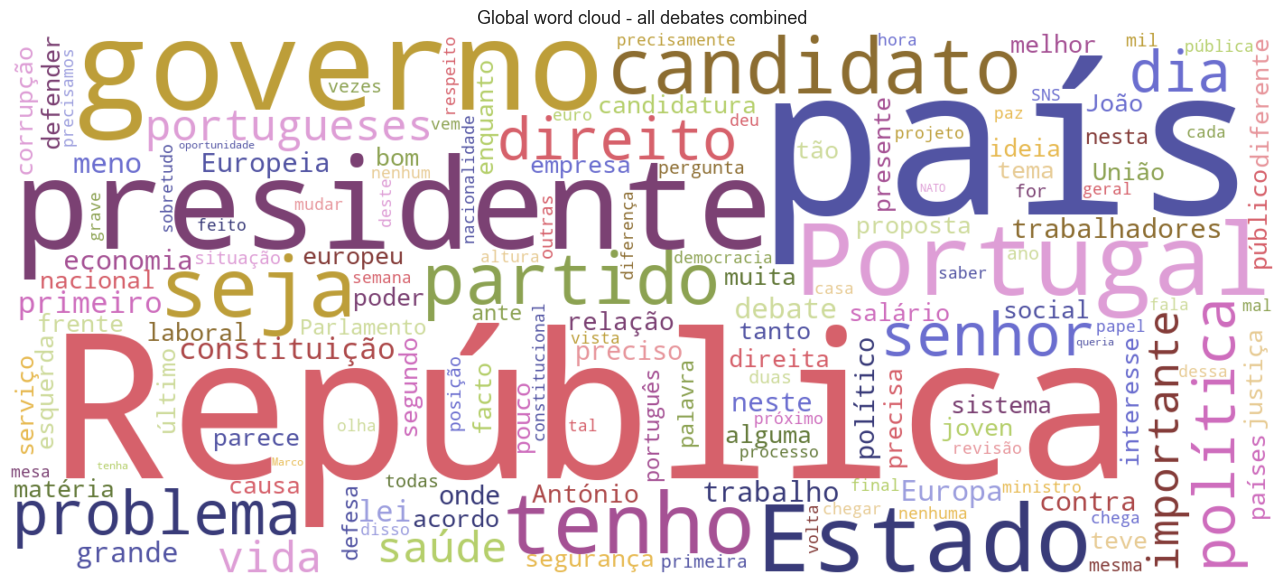

In [29]:
def make_wordcloud(text, title, ax):
    wc = WordCloud(
        width=600, height=300,
        background_color='white',
        stopwords=PT_STOPWORDS,
        max_words=80,
        colormap='tab20',
        min_word_length=3,
        collocations=False
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=9)
    ax.axis('off')

n = len(debate_videos)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3.5))
axes = axes.flatten()

for i, video_name in enumerate(sorted(debate_videos)):
    sub = speech_debates[speech_debates['video'] == video_name]
    full_text = ' '.join(sub['transcript'].dropna().astype(str).tolist())
    title = video_name.replace('_', ' ').replace(' vs ', '\nvs ').replace('November', 'Nov').replace('December', 'Dec')
    make_wordcloud(full_text, title, axes[i])

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Word clouds per debate (Portuguese stopwords removed)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

all_text = ' '.join(speech_debates['transcript'].dropna().astype(str).tolist())

fig, ax = plt.subplots(figsize=(14, 6))
wc_global = WordCloud(
    width=1400, height=600,
    background_color='white',
    stopwords=PT_STOPWORDS,
    max_words=150,
    colormap='tab20b',
    min_word_length=3,
    collocations=False
).generate(all_text)

ax.imshow(wc_global, interpolation='bilinear')
ax.axis('off')
ax.set_title('Global word cloud - all debates combined', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Bigrams  

Global token total used for bigrams: 45071


,bigram,count,per_1000_tokens
0,presidente república,144,3.19
1,união europeia,82,1.82
2,partido socialista,37,0.82
3,primeiro ministro,36,0.80
4,presente república,36,0.80
5,assembleia república,31,0.69
6,andré ventura,29,0.64
7,cima mesa,26,0.58
8,catarina martins,26,0.58
9,segunda volta,25,0.55


,video,n_tokens,bigram,count,per_1000_tokens
0,Cotrim_Figueiredo_vs_Filipe_November_30,1924,presidente república,9,4.68
1,Cotrim_Figueiredo_vs_Filipe_November_30,1924,sair euro,4,2.08
2,Cotrim_Figueiredo_vs_Filipe_November_30,1924,antonio felipe,3,1.56
3,Cotrim_Figueiredo_vs_Filipe_November_30,1924,união europeia,3,1.56
4,Cotrim_Figueiredo_vs_Filipe_November_30,1924,serviço social,3,1.56
5,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,717,semana passada,3,4.18
6,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,717,passado partidário,2,2.79
7,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,717,estéreio influência,2,2.79
8,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,717,primeiro ministro,2,2.79
9,Cotrim_Figueiredo_vs_Gouveia_Melo_November_20,717,tentou tentou,2,2.79


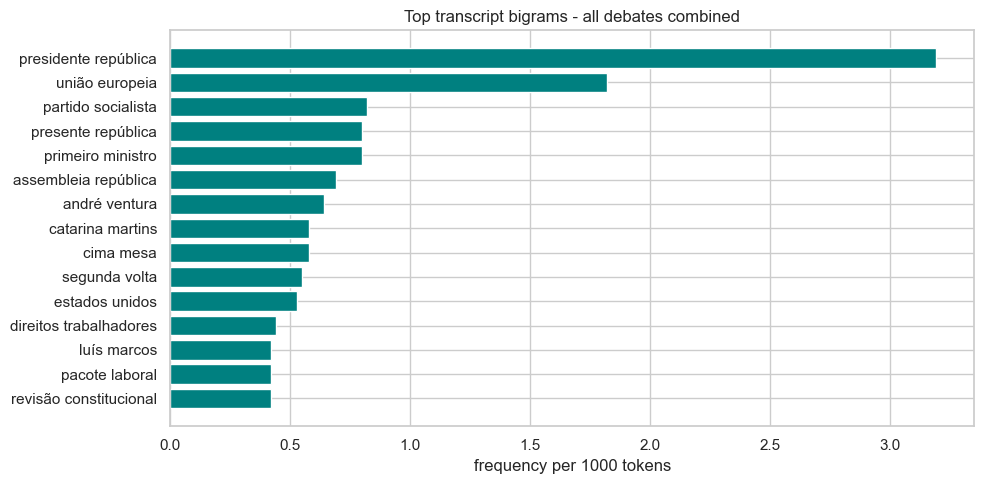

In [30]:
transcript_eda = speech_debates.copy()
transcript_eda['tokens_eda'] = transcript_eda['transcript'].apply(
    lambda t: tokenize_transcript(t, stopwords=PT_STOPWORDS, min_len=3)
)

def top_bigrams_for_group(token_lists, top_n=10):
    counter = Counter()
    total_tokens = 0
    for tokens in token_lists:
        total_tokens += len(tokens)
        counter.update(zip(tokens, tokens[1:]))
    rows = []
    for bg, count in counter.most_common(top_n):
        rows.append({
            'bigram': ' '.join(bg),
            'count': count,
            'per_1000_tokens': round(1000 * count / max(total_tokens, 1), 2)
        })
    return pd.DataFrame(rows), total_tokens

global_bigram_df, global_token_total = top_bigrams_for_group(transcript_eda['tokens_eda'], top_n=15)
print(f'Global token total used for bigrams: {global_token_total}')
display(global_bigram_df)

debate_bigram_rows = []
for video, sub in transcript_eda.groupby('video'):
    tbl, total_tokens = top_bigrams_for_group(sub['tokens_eda'], top_n=5)
    if not tbl.empty:
        tmp = tbl.copy()
        tmp.insert(0, 'video', video)
        tmp.insert(1, 'n_tokens', total_tokens)
        debate_bigram_rows.append(tmp)

debate_bigram_df = pd.concat(debate_bigram_rows, ignore_index=True)
display(debate_bigram_df.head(50))

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = global_bigram_df.sort_values('per_1000_tokens', ascending=True)
ax.barh(plot_df['bigram'], plot_df['per_1000_tokens'], color='teal', edgecolor='white')
ax.set_title('Top transcript bigrams - all debates combined')
ax.set_xlabel('frequency per 1000 tokens')
plt.tight_layout()
plt.show()

## 9. Pairwise cosine distance of debate topic (transcript embeddings)

Each debate is represented by the mean of its speech-segment text embeddings.
Cosine distance between those centroids shows which debates covered similar topics.
Section 9.1 uses the most semantically distant pair for a word-cloud contrast.

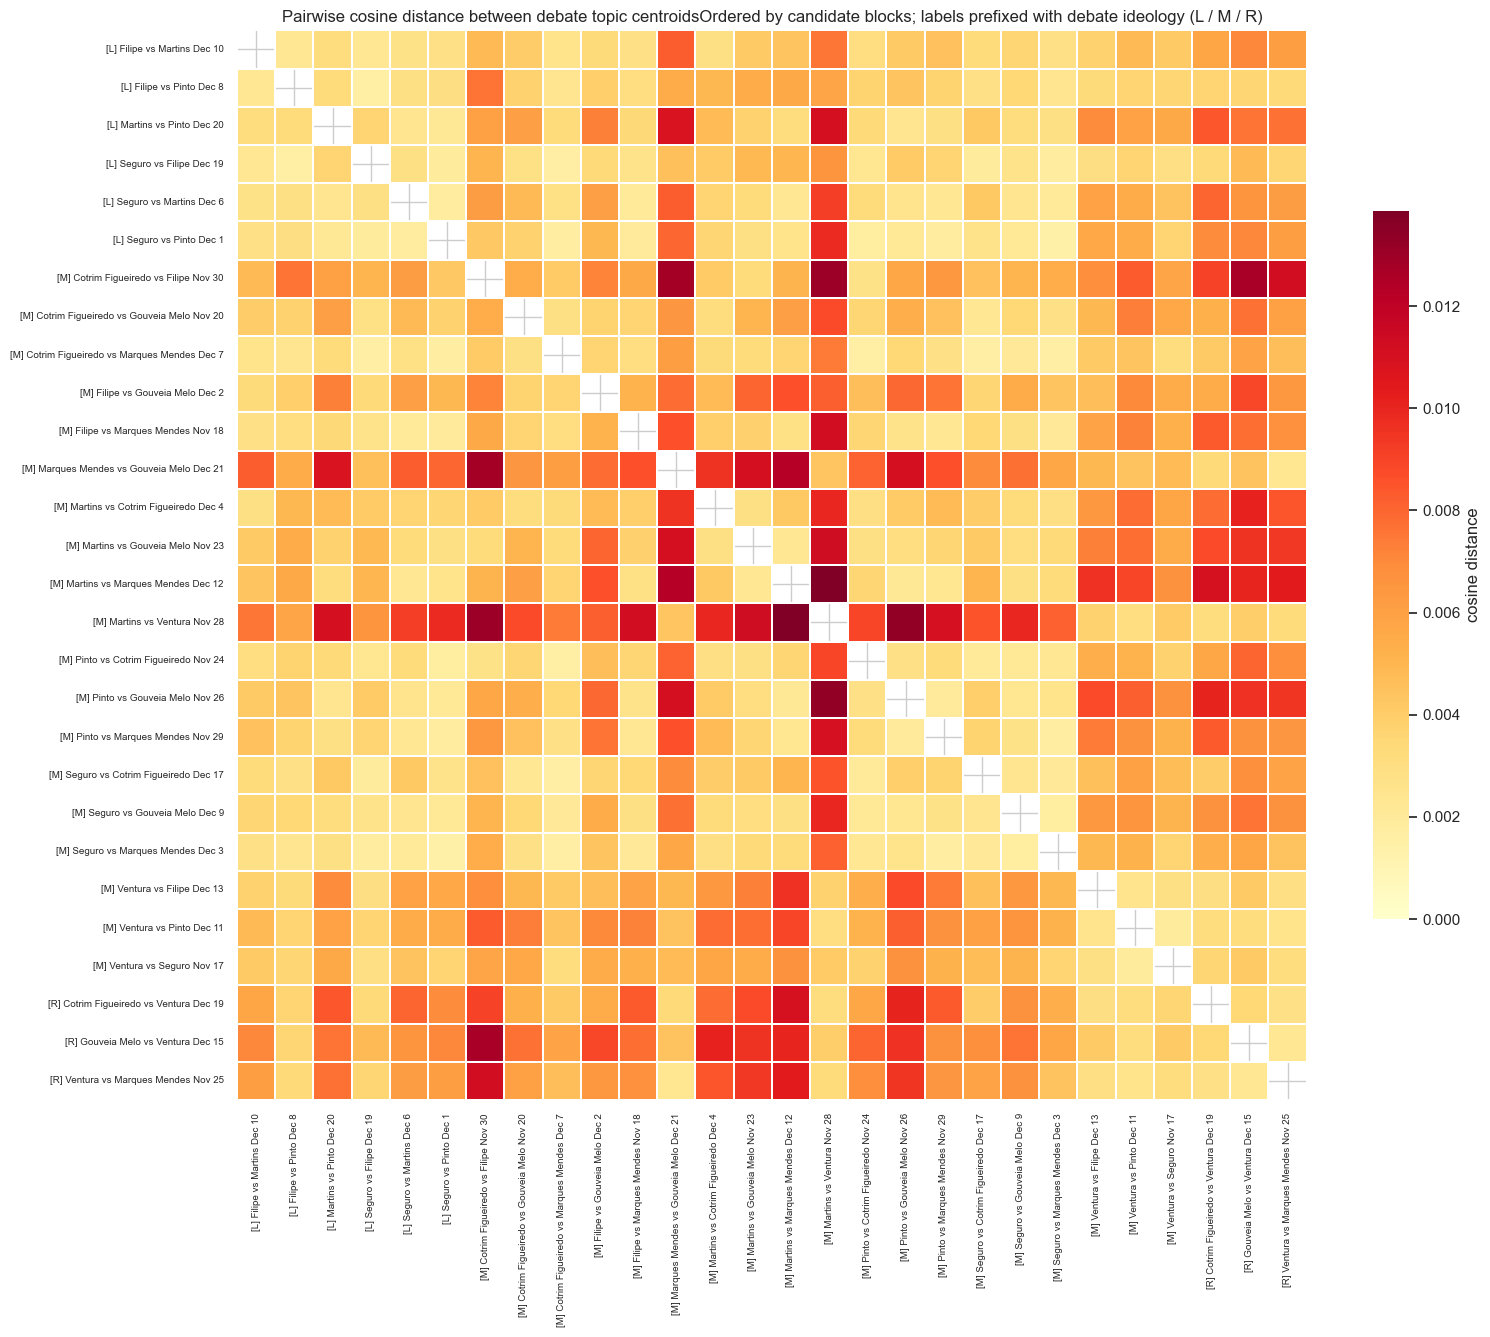

In [31]:
emb_col = 'text_embedding'

# Ideology blocks (determines label prefix and sort order)
IDEOLOGY = {
    'Filipe':            'L',   # CDU
    'Martins':           'L',   # BE
    'Pinto':             'L',   # Livre
    'Seguro':            'L',   # PS
    'Gouveia_Melo':      'M',   # Independent
    'Cotrim_Figueiredo': 'M',   # IL
    'Marques_Mendes':    'M',   # PSD+CDS
    'Ventura':           'R',   # CH
}
_LEV = {'L': 0, 'M': 1, 'R': 2}

CAND_LIST = ['Cotrim_Figueiredo', 'Filipe', 'Gouveia_Melo',
             'Marques_Mendes', 'Martins', 'Pinto', 'Seguro', 'Ventura']

def parse_text_embedding(x):
    if isinstance(x, np.ndarray):
        return x
    return np.fromstring(str(x).strip('[]'), sep=' ')

def _extract_cands(v):
    for cA in CAND_LIST:
        if v.startswith(cA + '_vs_'):
            rest = v[len(cA) + 4:]
            for cB in CAND_LIST:
                if rest.startswith(cB):
                    return cA, cB
    return None, None

def _debate_block(cA, cB):
    la = _LEV.get(IDEOLOGY.get(cA, 'M'), 1)
    lb = _LEV.get(IDEOLOGY.get(cB, 'M'), 1)
    mx, mn = max(la, lb), min(la, lb)
    if mx == 0: return 'L'
    if mx == 2 and mn >= 1: return 'R'
    return 'M'

def _pretty(v, block):
    s = (v.replace('_vs_', ' vs ').replace('_', ' ')
          .replace('November', 'Nov').replace('December', 'Dec'))
    return f'[{block}] {s}'

transcript_embed_debates = speech_debates.copy()
transcript_embed_debates[emb_col] = (
    transcript_embed_debates[emb_col].apply(parse_text_embedding))

debate_centroids = {}
for video, sub in transcript_embed_debates.groupby('video'):
    debate_centroids[video] = np.stack(sub[emb_col].values).mean(axis=0)

# Build sorted debate list with block labels
meta = []
for v in sorted(debate_centroids.keys()):
    cA, cB = _extract_cands(v)
    block = _debate_block(cA, cB) if cA else 'M'
    meta.append({'video': v, 'block': block, 'label': _pretty(v, block)})
meta.sort(key=lambda x: (_LEV[x['block']], x['video']))

debate_list = [m['video'] for m in meta]
labels      = [m['label'] for m in meta]
pretty_map  = {m['video']: m['label'] for m in meta}

centroid_matrix = np.stack([debate_centroids[v] for v in debate_list])
dist_matrix     = cdist(centroid_matrix, centroid_matrix, metric='cosine')

# Heatmap: cosine distance, diagonal excluded, sorted by ideology block
dist_display = dist_matrix.copy()
np.fill_diagonal(dist_display, np.nan)

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.isnan(dist_display)
sns.heatmap(
    pd.DataFrame(dist_display, index=labels, columns=labels),
    cmap='YlOrRd', vmin=0,
    square=True, linewidths=0.15, annot=False,
    mask=mask, ax=ax,
    cbar_kws={'shrink': 0.6, 'label': 'cosine distance'})
ax.set_title(
    'Pairwise cosine distance between debate topic centroids'
    'Ordered by candidate blocks; labels prefixed with debate ideology (L / M / R)',
    fontsize=12)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout()
plt.show()

# pair_df used by section 9.1
compare_pairs = []
for i, a in enumerate(debate_list):
    for j in range(i + 1, len(debate_list)):
        compare_pairs.append({'debate_a': a, 'debate_b': debate_list[j],
                               'semantic_distance': dist_matrix[i, j]})
pair_df = pd.DataFrame(compare_pairs).sort_values('semantic_distance').reset_index(drop=True)

### 9.1 Word-cloud contrast for the most semantically different debates


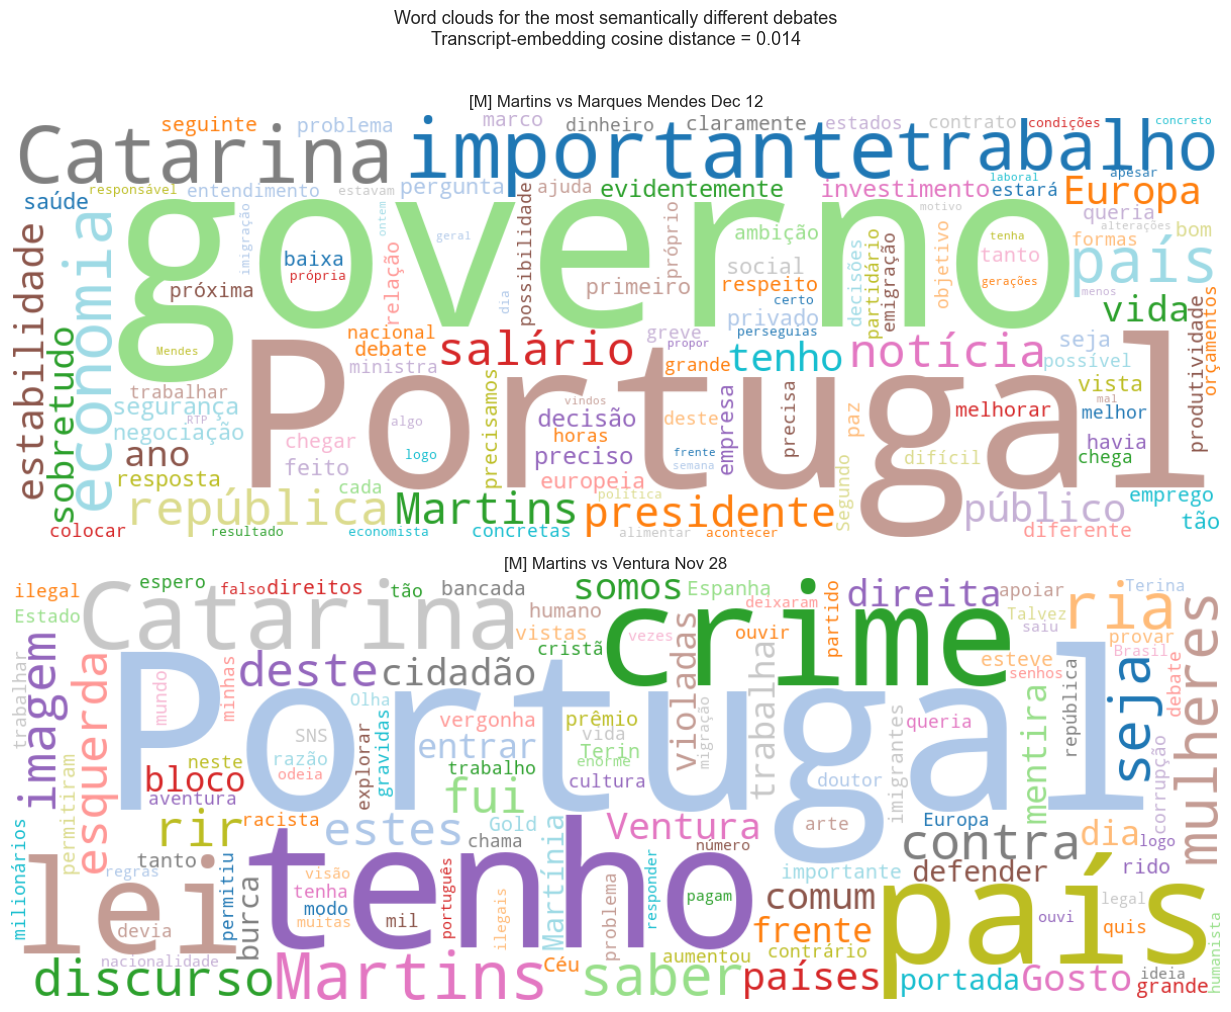

In [32]:
# Word clouds for the most semantically different debates from the global embedding matrix
# Uses the same full-debate semantic distance as pair_df above.

most_different_row = pair_df.sort_values('semantic_distance', ascending=False).iloc[0]
debate_a = most_different_row['debate_a']
debate_b = most_different_row['debate_b']

# Build transcript text lazily here so this cell works right after section 9.
debate_text_wc = (
    speech_debates.groupby('video')['transcript']
    .apply(lambda s: ' '.join(s.dropna().astype(str)))
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, debate_name in zip(axes, [debate_a, debate_b]):
    wc = WordCloud(
        width=1200, height=420,
        background_color='white',
        stopwords=PT_STOPWORDS,
        max_words=120,
        colormap='tab20',
        min_word_length=3,
        collocations=False
    ).generate(debate_text_wc.loc[debate_name])

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(pretty_map.get(debate_name, debate_name), fontsize=12)

plt.suptitle(
    'Word clouds for the most semantically different debates\n'
    f"Transcript-embedding cosine distance = {most_different_row['semantic_distance']:.3f}",
    fontsize=13,
    y=1.01
)
plt.tight_layout()
plt.show()
